<a href="https://colab.research.google.com/github/AlexDMP/SA-in-QRS-complex-detection/blob/main/Optimizaci%C3%B3nECGconSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# %% [code]
# =============================================================================
# Celda 1: Preparación del entorno de ejecución para el proyecto
# =============================================================================
# Esta celda se encarga de:
#  - Instalar e importar las librerías necesarias.
#  - Configurar variables globales y parámetros iniciales.
#  - Definir rutas para los datos y los resultados.
#  - Establecer configuraciones para reproducibilidad y logging.
#
# Las librerías utilizadas incluyen:
#  - wfdb: para la lectura y manejo de registros ECG de bases como MITDB e INCART.
#  - numpy, scipy y matplotlib: para procesamiento numérico, filtrado y visualización.
#  - pandas: para manipulación de datos/tablas si es necesario.
#  - logging: para depuración y seguimiento del flujo del programa.
#
# Además, se configuran parámetros globales que se usarán a lo largo de todas las celdas,
# facilitando la modificación centralizada y la experimentación.
# =============================================================================

# --- Instalación de librerías (si se ejecuta en Colab, se pueden instalar paquetes que no estén presentes)
!pip install -q wfdb  # wfdb es fundamental para trabajar con bases de datos ECG.
!pip install -q pandas

# --- Importación de librerías necesarias
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import wfdb  # Para cargar y manipular registros ECG
import pandas as pd
import random
import os
import logging

# --- Configuración de logging para registrar eventos y facilitar la depuración
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# --- Establecer semilla para reproducibilidad de resultados en experimentos
np.random.seed(42)
random.seed(42)

# --- Definición de parámetros globales y variables de configuración

# Parámetros de muestreo (valor por defecto para registros de MITDB; ajustar si se conoce otro valor para INCART)
DEFAULT_SAMPLING_RATE = 360  # Hz

# Parámetros de visualización: duración del segmento a mostrar (en segundos)
SEGMENTO_VISUALIZACION = 10

# Configuración de canales según la base de datos:
# Para MITDB se asume que el registro tiene 2 canales, y para INCART se usan 12 canales.
CANALES_MITDB = [0, 1]
CANALES_INCART = list(range(12))

# Selección de base de datos y registro por defecto (fácil de modificar para cambiar entre MITDB e INCART)
DATASET_POR_DEFECTO = 'mitdb'  # Alternativas: 'mitdb' o 'incartdb'
REGISTRO_POR_DEFECTO = '100'    # Ejemplo: '100', '101', 'I0', etc.

# Parámetros iniciales para los métodos de detección (estos valores son ajustables según resultados y pruebas)
PARAMETROS_DETECCION = {
    'hilbert': {'threshold': 0.5},       # Umbral de detección para el método de Hilbert
    'pan_tompkins': {'threshold': 0.3, 'window_size': 150},  # Umbral y tamaño de ventana para Pan-Tompkins
    'dpi': {'threshold': 0.4}              # Umbral para el método DPI (definir con base en investigación)
}

# Parámetros para el recocido simulado (Simulated Annealing), que se ajustarán en la celda correspondiente
PARAMETROS_RECOCIDO_SIMULADO = {
    'temperatura_inicial': 1000,
    'tasa_enfriamiento': 0.95,
    'iteraciones': 1000,
    'min_temperatura': 1e-3,
}

# Rutas para los datos y resultados:
# Se pueden montar unidades de Google Drive o ajustar la ruta según la estructura local de Colab
RUTA_DATOS = '/content/datos_ecg/'         # Carpeta donde se almacenarán las bases de datos
RUTA_RESULTADOS = '/content/resultados_ecg/' # Carpeta para guardar resultados, gráficos, tablas, etc.

# Crear las carpetas si no existen para evitar errores en la escritura de archivos
os.makedirs(RUTA_DATOS, exist_ok=True)
os.makedirs(RUTA_RESULTADOS, exist_ok=True)

# Comentarios adicionales:
# - Estas configuraciones permiten modificar de forma centralizada aspectos críticos del proyecto,
#   como la selección de la base de datos, el registro, canales y parámetros de detección.
# - Se incluyen parámetros iniciales que serán ajustados a lo largo del proyecto con base en la experimentación,
#   análisis de sensibilidad y comparaciones con la literatura.
# - La configuración de logging y la semilla establecen un entorno controlado y reproducible,
#   fundamental para un trabajo de excelencia académica.
# - Se recomienda revisar y actualizar estos parámetros conforme se avance en el desarrollo y se realicen pruebas.

logging.info("Entorno de ejecución configurado exitosamente. Listo para comenzar con la carga de datos y procesamiento.")


In [ ]:
# %% [code]
# =============================================================================
# Celda 2: Carga Inteligente de Datos de ECG desde Bases MITDB e INCARTDB
# =============================================================================
# Esta celda contiene la definición de la clase DataLoader, la cual:
#   - Permite seleccionar la base de datos (MITDB o INCARTDB) de forma modular.
#   - Verifica si un registro específico existe en la configuración de la base.
#   - Carga el registro ECG (señal cruda) y sus anotaciones (latidos) utilizando wfdb.
#
# Se utiliza la variable global DATABASE_CONFIG para definir parámetros esenciales de
# cada base (frecuencia de muestreo, número de canales y registros disponibles).
# La clase está diseñada para facilitar cambios entre bases y registros sin alterar el
# resto del código del proyecto.
# =============================================================================

# Configuración global para las bases de datos ECG
DATABASE_CONFIG = {
    'incartdb': {
        'fs': 257,
        'channels': 12,
        'records': ['I01']  # Registros disponibles en INCARTDB
    },
    'mitdb': {
        'fs': 360,
        'channels': 2,
        'records': ['100', '101']  # Registros disponibles en MITDB
    }
}

# Variable global para seleccionar la base de datos.
# Si no se ha definido previamente, se asigna un valor por defecto ('mitdb').
try:
    DB_SELECTOR = 'mitdb'
except NameError:
    DB_SELECTOR = 'mitdb'  # Alternativa: 'incartdb' o 'incart'

class DataLoader:
    def __init__(self, db_name):
        # Si se ingresa 'incart' se corrige a 'incartdb' para acceder a la base real
        self.db_name = 'incartdb' if db_name.lower() in ['incart', 'incartdb'] else db_name.lower()
        # Se mantiene la configuración original asociada al dataset
        self.config = DATABASE_CONFIG[self.db_name]

    def check_record_exists(self, record_id):
        """
        Verifica si el registro especificado existe en la configuración de la base de datos.

        Args:
            record_id (str): ID del registro (por ejemplo, '100' o 'I01').

        Returns:
            bool: True si el registro existe, False en caso contrario.
        """
        return record_id in self.config.get('records', [])

    def load_record(self, record_id):
        """
        Carga el registro ECG y sus anotaciones (latidos) utilizando wfdb.

        Args:
            record_id (str): ID del registro a cargar.

        Returns:
            dict or None: Diccionario con:
                - 'raw_signal': Señal cruda (numpy array) del registro.
                - 'annotations': Vector de anotaciones (latidos).
                - 'fs': Frecuencia de muestreo definida en la configuración.
                - 'channels': Número de canales definido en la configuración.
            o None en caso de error.
        """
        try:
            # Cargar la señal utilizando wfdb.rdsamp; se usa 'pn_dir' para acceder a PhysioNet
            record = wfdb.rdsamp(record_id, pn_dir=self.db_name)
            # Cargar las anotaciones. Se utiliza 'atr' como extensión (ajustable según la base)
            annotations = wfdb.rdann(record_id, 'atr', pn_dir=self.db_name)
            # Retornar la información en un diccionario
            return {
                'raw_signal': record[0],
                'annotations': annotations.sample,
                'fs': self.config['fs'],
                'channels': self.config['channels']
            }
        except Exception as e:
            print(f"Error: {str(e)}. ¿Usaste el nombre correcto de la base?")
            return None

# Ejemplo de uso:
# Se crea una instancia del DataLoader utilizando el selector de base de datos.
data_loader = DataLoader(DB_SELECTOR)

# Seleccionar un registro para cargar:
# - Para MITDB se recomienda '100' o '101'.
# - Para INCARTDB se recomienda 'I01'.
registro_id = 'I01' if DB_SELECTOR in ['incart', 'incartdb'] else '100'

if data_loader.check_record_exists(registro_id):
    data = data_loader.load_record(registro_id)
    if data:
        print("✅ Registro cargado. Dimensiones:", data['raw_signal'].shape)
    else:
        print("❌ Error al cargar el registro.")
else:
    print(f"❌ El registro {registro_id} no existe en la configuración de {DB_SELECTOR}.")


✅ Registro cargado. Dimensiones: (650000, 2)


In [ ]:
# %% [code]
# =============================================================================
# Celda 3: Preprocesamiento de las Señales ECG
# =============================================================================
# En esta celda se implementa un pipeline de preprocesamiento que:
#   1. Aplica un filtro pasa banda (0.5 - 45 Hz) para eliminar la deriva de la línea base
#      y el ruido de alta frecuencia.
#   2. Aplica filtros notch para eliminar interferencias eléctricas de 50/60 Hz.
#   3. Normaliza cada canal de la señal de forma robusta (usando percentiles 5 y 95).
#
# La señal preprocesada se almacena en una variable (por ejemplo, registro_filtrado)
# y se usará en los pasos posteriores del trabajo.
#
# Este enfoque modular y flexible permite ajustar los parámetros de cada etapa de
# preprocesamiento conforme se realicen pruebas y análisis comparativos.
# =============================================================================

from scipy.signal import butter, filtfilt

class ECGPreprocessor:
    def __init__(self, fs):
        """
        Inicializa el preprocesador con la frecuencia de muestreo.

        Args:
            fs (float): Frecuencia de muestreo de la señal ECG.
        """
        self.fs = fs
        self.nyquist = 0.5 * fs

    def _design_filter(self, lowcut, highcut, order=4, filter_type='bandpass'):
        """
        Diseña un filtro Butterworth dado un rango de frecuencias.

        Args:
            lowcut (float): Frecuencia mínima (Hz) del filtro.
            highcut (float): Frecuencia máxima (Hz) del filtro.
            order (int): Orden del filtro.
            filter_type (str): Tipo de filtro ('bandpass' o 'bandstop').

        Returns:
            b, a: Coeficientes del filtro.
        """
        low = lowcut / self.nyquist
        high = highcut / self.nyquist
        b, a = butter(order, [low, high], btype=filter_type)
        return b, a

    def apply_bandpass_filter(self, signal_data, lowcut=0.5, highcut=45, order=4):
        """
        Aplica un filtro pasa banda para atenuar la deriva y el ruido fuera de la banda de interés.

        Args:
            signal_data (np.ndarray): Señal ECG cruda (n_samples x n_channels).
            lowcut (float): Frecuencia mínima del filtro (Hz).
            highcut (float): Frecuencia máxima del filtro (Hz).
            order (int): Orden del filtro.

        Returns:
            np.ndarray: Señal filtrada.
        """
        b, a = self._design_filter(lowcut, highcut, order, filter_type='bandpass')
        filtered_signal = filtfilt(b, a, signal_data, axis=0)
        return filtered_signal

    def apply_notch_filters(self, signal_data, freqs=[50, 60], bandwidth=2, order=2):
        """
        Aplica filtros notch (bandstop) para eliminar interferencias en frecuencias específicas.

        Args:
            signal_data (np.ndarray): Señal (cruda o filtrada) (n_samples x n_channels).
            freqs (list): Lista de frecuencias (Hz) a eliminar (por ejemplo, [50, 60]).
            bandwidth (float): Ancho de banda (Hz) a atenuar alrededor de cada frecuencia.
            order (int): Orden del filtro notch.

        Returns:
            np.ndarray: Señal con las interferencias atenuadas.
        """
        cleaned_signal = signal_data.copy()
        for freq in freqs:
            if freq < self.nyquist:
                lowcut = freq - bandwidth / 2
                highcut = freq + bandwidth / 2
                b, a = self._design_filter(lowcut, highcut, order, filter_type='bandstop')
                cleaned_signal = filtfilt(b, a, cleaned_signal, axis=0)
        return cleaned_signal

    def robust_normalization(self, signal_data):
        """
        Normaliza cada canal de la señal utilizando percentiles (5 y 95) para obtener robustez ante valores atípicos.

        Args:
            signal_data (np.ndarray): Señal ECG (n_samples x n_channels).

        Returns:
            np.ndarray: Señal normalizada.
        """
        normalized_signal = np.empty_like(signal_data)
        for ch in range(signal_data.shape[1]):
            p5 = np.percentile(signal_data[:, ch], 5)
            p95 = np.percentile(signal_data[:, ch], 95)
            if p95 - p5 > 0:
                normalized_signal[:, ch] = (signal_data[:, ch] - p5) / (p95 - p5)
            else:
                normalized_signal[:, ch] = signal_data[:, ch]
        return normalized_signal

    def full_pipeline(self, raw_signal):
        """
        Ejecuta el pipeline completo de preprocesamiento:
          1. Filtrado pasa banda (0.5 - 45 Hz).
          2. Aplicación de filtros notch para 50/60 Hz.
          3. Normalización robusta por canal.

        Args:
            raw_signal (np.ndarray): Señal ECG cruda (n_samples x n_channels).

        Returns:
            np.ndarray: Señal preprocesada lista para análisis.
        """
        # Paso 1: Filtrado pasa banda
        filtered_signal = self.apply_bandpass_filter(raw_signal, lowcut=0.5, highcut=45, order=4)
        # Paso 2: Eliminación de interferencia eléctrica (filtros notch)
        cleaned_signal = self.apply_notch_filters(filtered_signal, freqs=[50, 60], bandwidth=2, order=2)
        # Paso 3: Normalización robusta
        processed_signal = self.robust_normalization(cleaned_signal)
        return processed_signal

# Ejemplo de uso:
# Se asume que 'data' es el diccionario obtenido en la Celda 2,
# conteniendo la señal cruda ('raw_signal'), frecuencia de muestreo ('fs') y otros parámetros.
if data:
    preprocessor = ECGPreprocessor(fs=data['fs'])
    processed_signal = preprocessor.full_pipeline(data['raw_signal'])
    # Guardamos la señal procesada en una variable identificable (por ejemplo, registro_filtrado)
    registro_filtrado = processed_signal
    print("✅ Procesado exitoso. Formato:", processed_signal.shape)


✅ Procesado exitoso. Formato: (650000, 2)


In [ ]:
# %% [code]
# =============================================================================
# Celda 4: Función de Evaluación de Detecciones de Latidos
# =============================================================================
# Esta función evalúa las detecciones de latidos comparándolas con las anotaciones
# de referencia (ground truth), utilizando un parámetro de tolerancia para el emparejamiento.
#
# Las métricas calculadas incluyen:
#   - Sensibilidad (%): Capacidad de detectar latidos reales.
#   - Precisión (%): Porcentaje de detecciones correctas.
#   - F1-Score (%): Media armónica de sensibilidad y precisión.
#   - Latencia Media (s) y Desviación Estándar de Latencia (s): Diferencia temporal
#     entre la detección y la anotación emparejada.
#   - Consistencia RR (s): Desviación estándar de los intervalos RR de las anotaciones.
#
# Se utiliza un parámetro 'tolerance' (en segundos) para definir el margen de error aceptable
# en el emparejamiento entre detección y anotación.
# =============================================================================

import numpy as np

def evaluate_detections(detections, annotations, fs, tolerance=0.1):
    """
    Evalúa las detecciones de latidos mediante un emparejamiento uno a uno con las anotaciones.

    Args:
        detections (array-like): Índices (en muestras) de picos detectados.
        annotations (array-like): Índices (en muestras) de latidos anotados (ground truth).
        fs (int or float): Frecuencia de muestreo (Hz).
        tolerance (float): Tolerancia en segundos para considerar una detección correcta.

    Returns:
        dict: Métricas de evaluación, incluyendo sensibilidad, precisión, F1-Score,
              latencia media, desviación estándar de la latencia y consistencia RR.
    """
    # Convertir a arrays NumPy y asegurarse de que estén ordenados
    detections = np.sort(np.array(detections))
    annotations = np.sort(np.array(annotations))

    tol_samples = tolerance * fs  # Tolerancia en número de muestras
    tp = 0  # Verdaderos positivos
    latencies = []  # Diferencias entre detecciones y anotaciones
    used_detection = np.zeros(len(detections), dtype=bool)  # Para evitar emparejamientos múltiples

    # Para cada anotación se busca la detección no usada más cercana que esté dentro de la tolerancia
    for ann in annotations:
        diffs = np.abs(detections - ann)
        # Encontrar índices de detecciones que cumplan la condición y que aún no hayan sido usadas
        posibles = np.where((diffs <= tol_samples) & (~used_detection))[0]
        if posibles.size > 0:
            # Se elige la detección con la mínima diferencia
            idx = posibles[np.argmin(diffs[posibles])]
            tp += 1
            latencies.append(detections[idx] - ann)
            used_detection[idx] = True

    fp = np.sum(~used_detection)  # Detecciones sobrantes que no fueron emparejadas
    fn = len(annotations) - tp   # Anotaciones no detectadas

    sensitivity = (tp / (tp + fn) * 100) if (tp + fn) > 0 else 0
    precision   = (tp / (tp + fp) * 100) if (tp + fp) > 0 else 0
    f1_score    = (2 * precision * sensitivity / (precision + sensitivity)) if (precision + sensitivity) > 0 else 0

    # Cálculo de latencia: se convierte a segundos
    if latencies:
        mean_latency = np.mean(latencies) / fs
        std_latency  = np.std(latencies) / fs
    else:
        mean_latency, std_latency = 0, 0

    # Consistencia RR: se calcula a partir de las anotaciones (ground truth)
    if len(annotations) > 1:
        rr_intervals = np.diff(annotations) / fs  # En segundos
        rr_consistency = np.std(rr_intervals)
    else:
        rr_consistency = 0

    return {
        'Sensibilidad (%)': sensitivity,
        'Precisión (%)': precision,
        'F1-Score (%)': f1_score,
        'Latencia Media (s)': mean_latency,
        'Desviación Estándar de Latencia (s)': std_latency,
        'Consistencia RR (s)': rr_consistency,
        'TP': tp,
        'FP': int(fp),
        'FN': fn
    }

# Prueba de la función de evaluación:
# Si 'data' está disponible (obtenido en Celda 2), se usa las anotaciones como detecciones
if data:
    # Utilizamos las anotaciones como detecciones para realizar una prueba de "sanity check"
    annotations = data['annotations']
    metrics = evaluate_detections(annotations, annotations, data['fs'], tolerance=0.1)
    print("Métricas de evaluación (prueba con anotaciones):", metrics)


Métricas de evaluación (prueba con anotaciones): {'Sensibilidad (%)': 100.0, 'Precisión (%)': 100.0, 'F1-Score (%)': 100.0, 'Latencia Media (s)': 0.0, 'Desviación Estándar de Latencia (s)': 0.0, 'Consistencia RR (s)': 0.05058434099145012, 'TP': 2274, 'FP': 0, 'FN': 0}


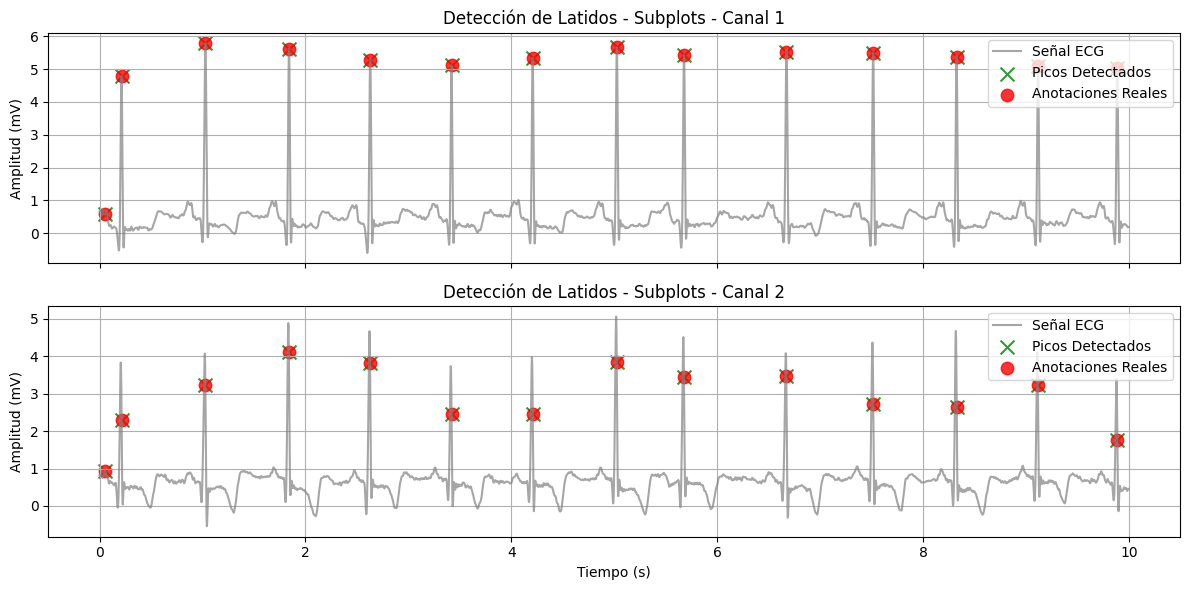

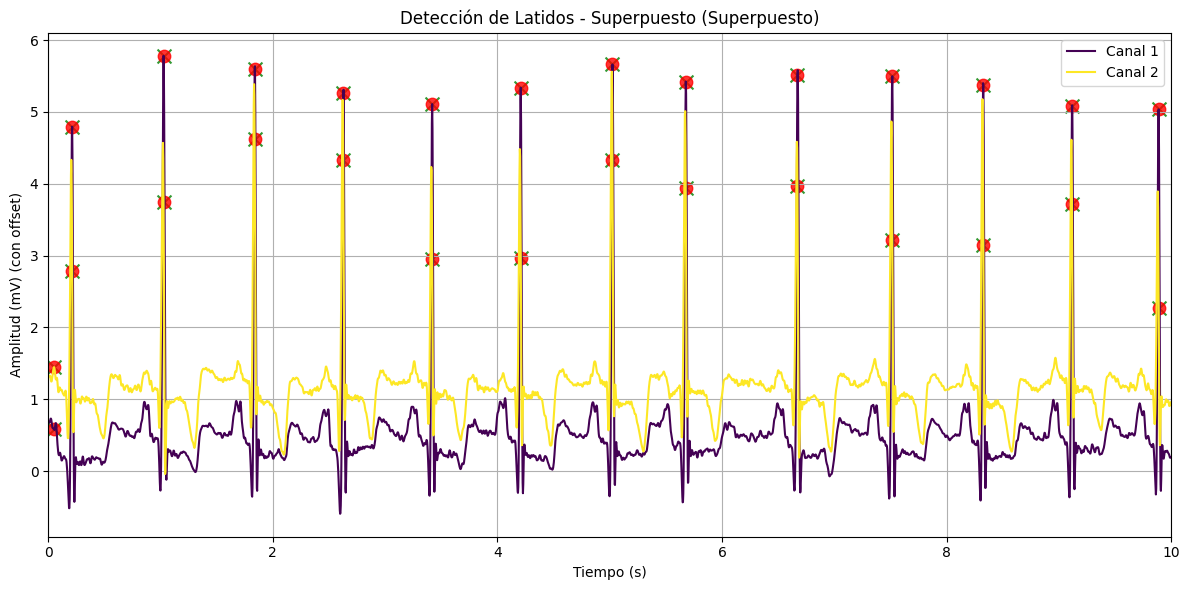

In [ ]:
# %% [code]
# =============================================================================
# Celda 6: Función de Visualización de Señales ECG con Detecciones y Anotaciones
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_ecg_with_peaks(signal, fs, detected_peaks, annotations=None, channels_to_display=None,
                        start_time=None, end_time=None, title="Detección de Latidos",
                        superimposed=False, offset=0.0):
    """
    Grafica la señal ECG con los picos detectados y las anotaciones, en un segmento de tiempo configurable.

    Se pueden visualizar los canales en subplots separados o superpuestos en una única gráfica.

    Args:
        signal (np.ndarray): Matriz de la señal ECG con forma (n_samples, n_channels).
        fs (int or float): Frecuencia de muestreo (Hz).
        detected_peaks (array-like): Índices (en muestras) de picos detectados.
        annotations (array-like, opcional): Índices (en muestras) de latidos anotados (ground truth).
        channels_to_display (list, opcional): Lista de índices de canales a visualizar. Si None, se muestran todos.
        start_time (float, opcional): Tiempo de inicio (en segundos) del segmento a visualizar. Por defecto, 0.
        end_time (float, opcional): Tiempo de fin (en segundos) del segmento. Por defecto, duración total de la señal.
        title (str): Título base del gráfico.
        superimposed (bool): Si True, se grafican todos los canales en una única figura superpuestos.
        offset (float): Desplazamiento vertical entre canales (aplicable en modo superpuesto). Si 0, no se aplica.

    Returns:
        None. La función muestra la gráfica utilizando plt.show().
    """
    num_channels = signal.shape[1]

    # Determinar los canales a visualizar
    if channels_to_display is None:
        channels_to_display = list(range(num_channels))

    # Configurar límites de tiempo
    total_time = len(signal) / fs
    if start_time is None:
        start_time = 0.0
    if end_time is None or end_time > total_time:
        end_time = total_time

    # Convertir tiempos a índices de muestra
    start_index = int(start_time * fs)
    end_index = int(end_time * fs)
    time_axis = np.arange(start_index, end_index) / fs

    if not superimposed:
        # Graficar cada canal en subplots separados
        fig, axs = plt.subplots(len(channels_to_display), 1, figsize=(12, 3 * len(channels_to_display)), sharex=True)
        if len(channels_to_display) == 1:
            axs = [axs]  # Garantizar iterabilidad en caso de un único canal

        for i, ch in enumerate(channels_to_display):
            axs[i].plot(time_axis, signal[start_index:end_index, ch], color='gray', alpha=0.7, label='Señal ECG')

            # Detecciones en el segmento
            seg_peaks = detected_peaks[(detected_peaks >= start_index) & (detected_peaks < end_index)]
            axs[i].scatter(seg_peaks / fs, signal[seg_peaks, ch], color='green', marker='x', s=100, alpha=0.8, label='Picos Detectados')

            # Anotaciones (si están disponibles)
            if annotations is not None:
                seg_ann = annotations[(annotations >= start_index) & (annotations < end_index)]
                axs[i].scatter(seg_ann / fs, signal[seg_ann, ch], color='red', marker='o', s=80, alpha=0.8, label='Anotaciones Reales')

            axs[i].set_title(f"{title} - Canal {ch+1}")
            axs[i].set_ylabel("Amplitud (mV)")
            axs[i].grid(True)
            axs[i].legend(loc='upper right')
        axs[-1].set_xlabel("Tiempo (s)")
        plt.tight_layout()
        plt.show()

    else:
        # Graficar todos los canales superpuestos en una única gráfica
        plt.figure(figsize=(12, 6))
        # Asignar una paleta de colores para diferenciar los canales
        colors = plt.cm.viridis(np.linspace(0, 1, len(channels_to_display)))

        for idx, ch in enumerate(channels_to_display):
            # Calcular offset vertical para separar los canales si se desea
            channel_offset = offset * idx if offset != 0.0 else 0.0
            plt.plot(time_axis, signal[start_index:end_index, ch] + channel_offset, color=colors[idx],
                     label=f'Canal {ch+1}')
            # Detecciones
            seg_peaks = detected_peaks[(detected_peaks >= start_index) & (detected_peaks < end_index)]
            plt.scatter(seg_peaks / fs, signal[seg_peaks, ch] + channel_offset, color='green', marker='x',
                        s=100, alpha=0.8)
            # Anotaciones
            if annotations is not None:
                seg_ann = annotations[(annotations >= start_index) & (annotations < end_index)]
                plt.scatter(seg_ann / fs, signal[seg_ann, ch] + channel_offset, color='red', marker='o',
                            s=80, alpha=0.8)

        plt.title(title + " (Superpuesto)")
        plt.xlabel("Tiempo (s)")
        ylabel = "Amplitud (mV)"
        if offset != 0.0:
            ylabel += " (con offset)"
        plt.ylabel(ylabel)
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.xlim(start_time, end_time)
        plt.tight_layout()
        plt.show()


# Ejemplo de uso para probar la función de visualización:
if data:
    # Utilizar la señal preprocesada (por ejemplo, la variable 'processed_signal' definida en la Celda 3)
    signal = processed_signal
    # Para la prueba, se usan las anotaciones reales tanto como detecciones (sanity check)
    annotations = data['annotations']
    detected_peaks = annotations.copy()

    # Visualización en subplots separados por canal
    plot_ecg_with_peaks(signal, data['fs'], detected_peaks, annotations,
                        channels_to_display=None, start_time=0, end_time=10,
                        title="Detección de Latidos - Subplots", superimposed=False)

    # Visualización superpuesta de todos los canales (con un offset vertical de 0.5 mV para mayor claridad)
    plot_ecg_with_peaks(signal, data['fs'], detected_peaks, annotations,
                        channels_to_display=None, start_time=0, end_time=10,
                        title="Detección de Latidos - Superpuesto", superimposed=True, offset=0.5)


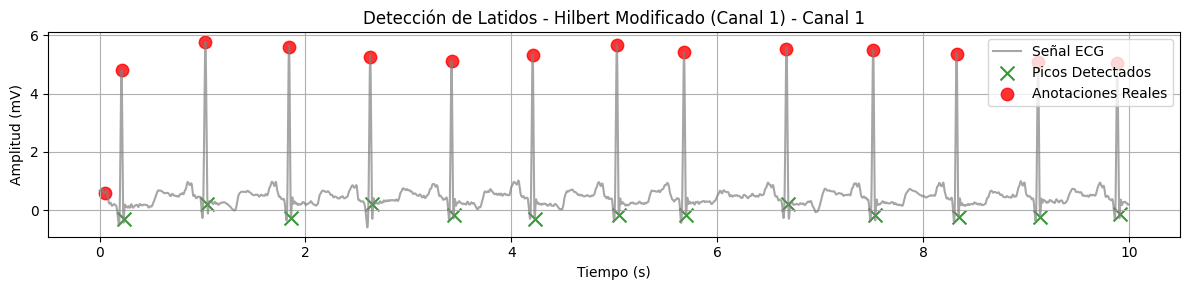

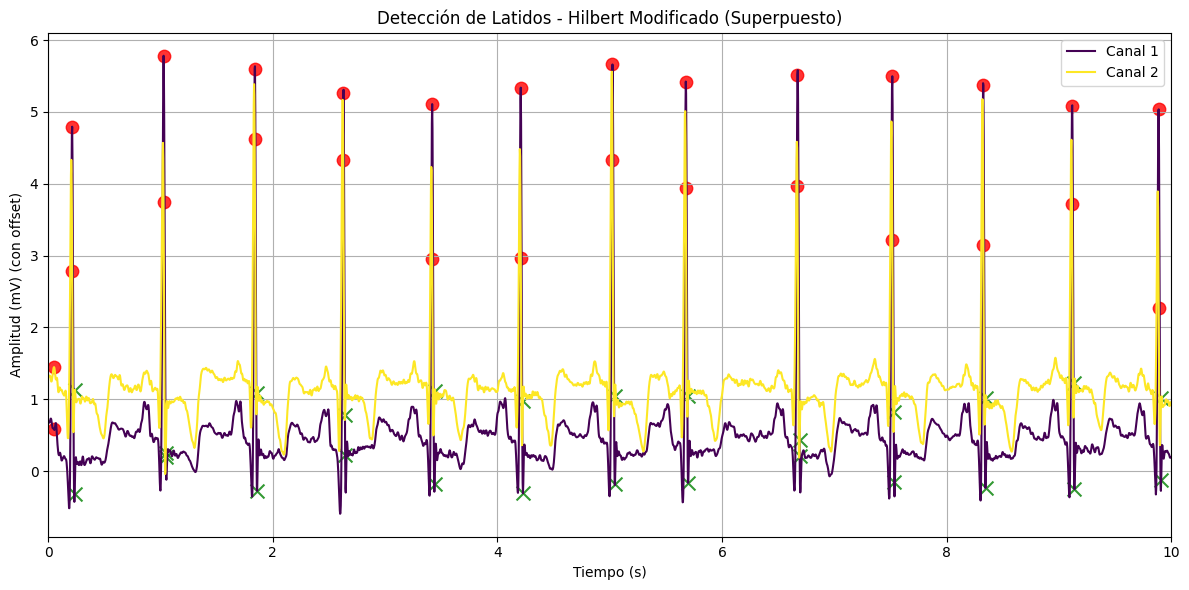

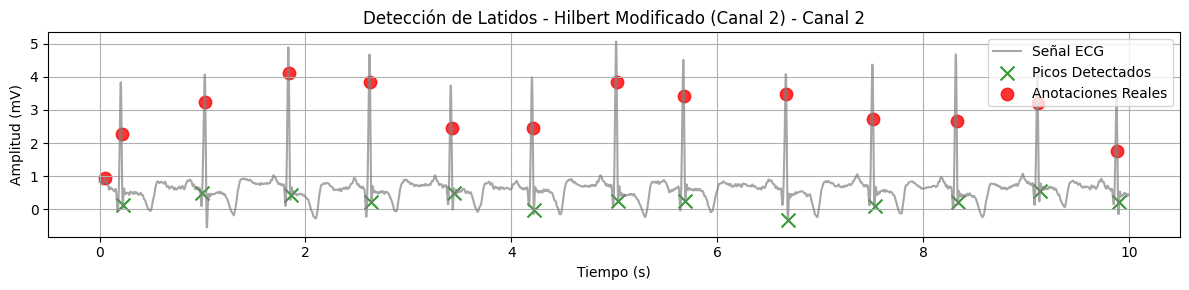

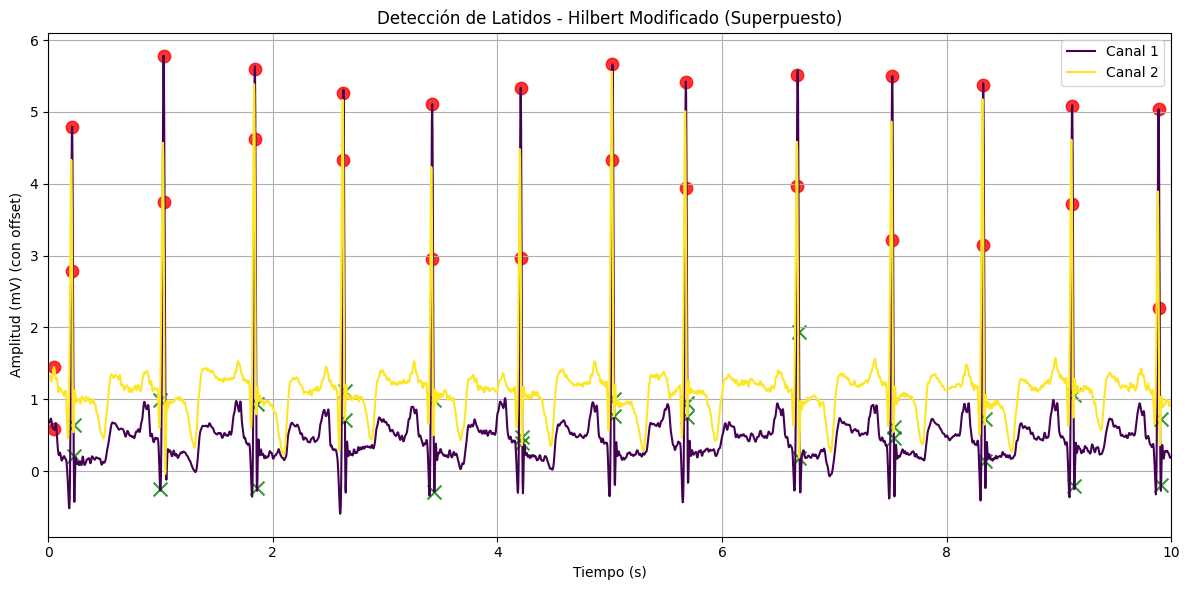

Resultados de Detección - Método Hilbert Modificado
| Canal | Sensibilidad (%) | Precisión (%) | F1-Score (%) | Latencia Media (s) | Desviación Estándar de Latencia (s) | Consistencia RR (s) |
|-------|------------------|---------------|--------------|--------------------|-------------------------------------|---------------------|
| 1 | 99.96 | 100.00 | 99.98 | 0.0181 | 0.0031 | 0.0506 |
| 2 | 99.82 | 100.00 | 99.91 | 0.0092 | 0.0117 | 0.0506 |
| Promedio | 99.89 | 100.00 | 99.94 | 0.0136 | 0.0074 | 0.0506 |


In [ ]:
# %% [code]
import numpy as np
from scipy.signal import hilbert, find_peaks

def detect_hilbert_modified(signal, fs, threshold_multiplier=0.1, smoothing_window_sec=0.1, min_distance_sec=0.5):
    """
    Detecta latidos en una señal utilizando la Transformada de Hilbert modificada,
    incorporando suavizado del envelope cuadrático y umbral adaptativo.

    Args:
        signal (np.ndarray): Señal de un canal (1D array) a procesar.
        fs (int or float): Frecuencia de muestreo.
        threshold_multiplier (float): Factor multiplicador para el cálculo del umbral adaptativo.
        smoothing_window_sec (float): Duración en segundos del filtro de suavizado aplicado al envelope.
        min_distance_sec (float): Distancia mínima entre picos (en segundos) para considerarlos latidos distintos.

    Returns:
        np.ndarray: Índices de los picos detectados.
    """
    # 1. Calcular la señal analítica y su envelope
    analytic_signal = hilbert(signal)
    envelope = np.abs(analytic_signal)

    # 2. Calcular el envelope cuadrático para resaltar la energía
    squared_envelope = envelope ** 2

    # 3. Suavizado del envelope mediante una ventana móvil (filtro de media)
    window_size = int(smoothing_window_sec * fs)
    window_size = max(window_size, 1)  # Evitar ventana vacía
    smoothing_kernel = np.ones(window_size) / window_size
    smoothed_envelope = np.convolve(squared_envelope, smoothing_kernel, mode='same')

    # 4. Calcular un umbral adaptativo basado en la media y la desviación estándar del envelope suavizado
    threshold = np.mean(smoothed_envelope) + threshold_multiplier * np.std(smoothed_envelope)

    # 5. Detección de picos con restricción de distancia mínima para evitar múltiples detecciones en un QRS
    min_distance_samples = int(min_distance_sec * fs)
    peaks, _ = find_peaks(smoothed_envelope, height=threshold, distance=min_distance_samples)

    return peaks

def run_hilbert_modified_detection(signal, fs, annotations, threshold_multiplier=0.1, smoothing_window_sec=0.1, min_distance_sec=0.5):
    """
    Ejecuta la detección de latidos por canal usando el método de Hilbert Modificado.

    Args:
        signal (np.ndarray): Señal ECG preprocesada con forma (n_samples, n_channels).
        fs (int or float): Frecuencia de muestreo.
        annotations (np.ndarray): Latidos anotados (ground truth).
        threshold_multiplier (float): Factor multiplicador para el umbral.
        smoothing_window_sec (float): Duración (en segundos) del filtro de suavizado.
        min_distance_sec (float): Distancia mínima entre picos (en segundos).

    Returns:
        dict: Resultados de evaluación por canal (métricas).
        list: Lista de detecciones por canal (índices de picos).
    """
    results_hilbert = {'Hilbert_Modified': {}}
    detections_per_channel = []

    for ch in range(signal.shape[1]):
        # Detección para el canal actual
        detected_peaks = detect_hilbert_modified(signal[:, ch], fs, threshold_multiplier, smoothing_window_sec, min_distance_sec)
        detections_per_channel.append(detected_peaks)

        # Evaluar las detecciones con la función de evaluación
        if detected_peaks.size > 0:
            metrics = evaluate_detections(detected_peaks, annotations, fs, tolerance=0.1)
        else:
            metrics = {
                'Sensibilidad (%)': 0,
                'Precisión (%)': 0,
                'F1-Score (%)': 0,
                'Latencia Media (s)': 0,
                'Desviación Estándar de Latencia (s)': 0,
                'Consistencia RR (s)': 0,
                'TP': 0,
                'FP': 0,
                'FN': len(annotations)
            }
        results_hilbert['Hilbert_Modified'][ch] = metrics

        # Visualización para un segmento representativo (por ejemplo, los primeros 10 segundos)
        plot_ecg_with_peaks(signal, fs, detected_peaks, annotations=annotations,
                            channels_to_display=[ch], start_time=0, end_time=10,
                            title=f"Detección de Latidos - Hilbert Modificado (Canal {ch+1})")
        # Visualización superpuesta de todos los canales (con un offset vertical de 0.5 mV para mayor claridad)
        plot_ecg_with_peaks(signal, fs, detected_peaks, annotations=annotations,
                          channels_to_display=None, start_time=0, end_time=10,
                          title=f"Detección de Latidos - Hilbert Modificado", superimposed=True, offset=0.5 )

    return results_hilbert, detections_per_channel

# Ejecución de la detección por Hilbert Modificado
if data:
    signal = processed_signal  # Señal preprocesada obtenida en la Celda 3
    annotations = data['annotations']  # Anotaciones reales
    results_hilbert_modified, detections_hilbert = run_hilbert_modified_detection(signal, data['fs'], annotations,
                                                                                   threshold_multiplier=0.1,
                                                                                   smoothing_window_sec=0.1,
                                                                                   min_distance_sec=0.5)

    # Reporte automático: Imprimir resultados en formato tabla
    print("Resultados de Detección - Método Hilbert Modificado")
    print("| Canal | Sensibilidad (%) | Precisión (%) | F1-Score (%) | Latencia Media (s) | Desviación Estándar de Latencia (s) | Consistencia RR (s) |")
    print("|-------|------------------|---------------|--------------|--------------------|-------------------------------------|---------------------|")
    for ch, metrics in results_hilbert_modified['Hilbert_Modified'].items():
        print(f"| {ch+1} | {metrics['Sensibilidad (%)']:.2f} | {metrics['Precisión (%)']:.2f} | {metrics['F1-Score (%)']:.2f} | {metrics['Latencia Media (s)']:.4f} | {metrics['Desviación Estándar de Latencia (s)']:.4f} | {metrics['Consistencia RR (s)']:.4f} |")

    # Calcular promedios de las métricas entre canales
    avg_sens = np.mean([m['Sensibilidad (%)'] for m in results_hilbert_modified['Hilbert_Modified'].values()])
    avg_prec = np.mean([m['Precisión (%)'] for m in results_hilbert_modified['Hilbert_Modified'].values()])
    avg_f1 = np.mean([m['F1-Score (%)'] for m in results_hilbert_modified['Hilbert_Modified'].values()])
    avg_latency = np.mean([m['Latencia Media (s)'] for m in results_hilbert_modified['Hilbert_Modified'].values()])
    avg_std_latency = np.mean([m['Desviación Estándar de Latencia (s)'] for m in results_hilbert_modified['Hilbert_Modified'].values()])
    avg_rr_consistency = np.mean([m['Consistencia RR (s)'] for m in results_hilbert_modified['Hilbert_Modified'].values()])

    # Imprimir promedios
    print(f"| Promedio | {avg_sens:.2f} | {avg_prec:.2f} | {avg_f1:.2f} | {avg_latency:.4f} | {avg_std_latency:.4f} | {avg_rr_consistency:.4f} |")


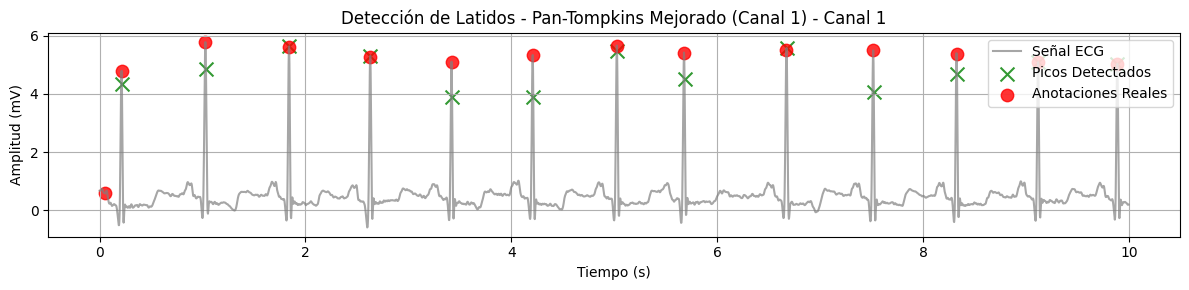

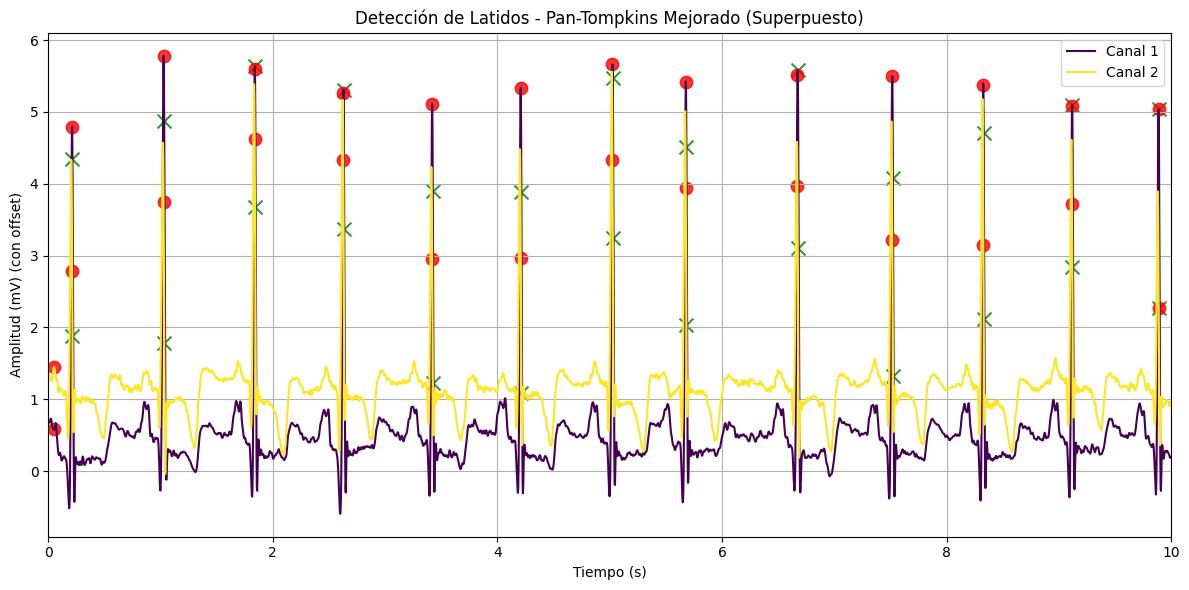

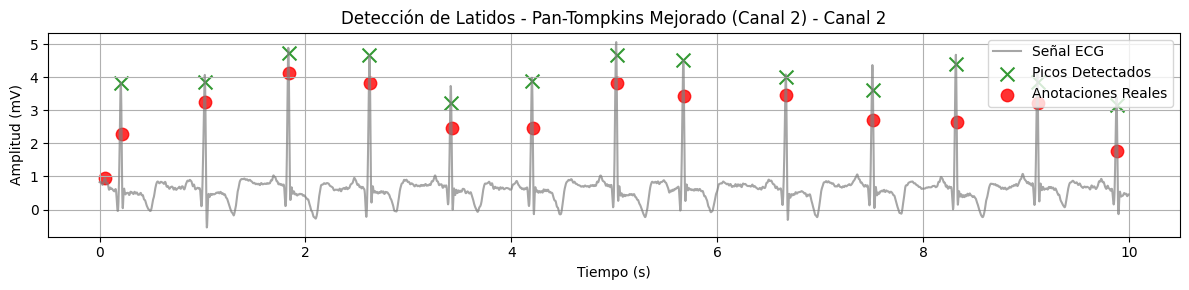

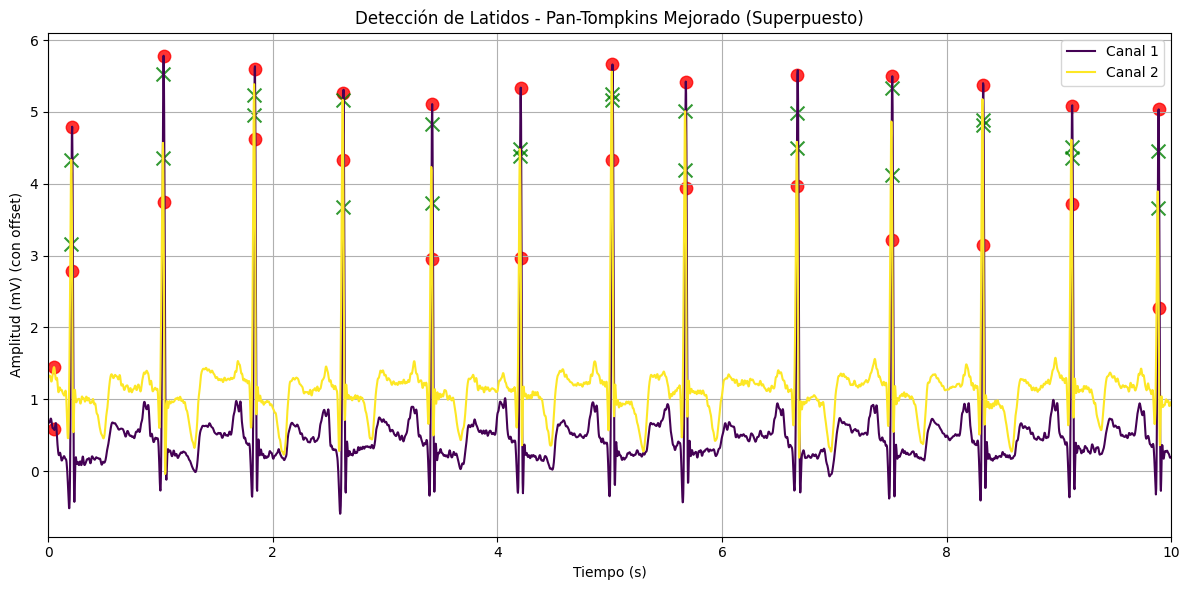

Resultados de Detección - Método Pan-Tompkins Mejorado
| Canal | Sensibilidad (%) | Precisión (%) | F1-Score (%) | Latencia Media (s) | Desviación Estándar de Latencia (s) | Consistencia RR (s) |
|-------|------------------|---------------|--------------|--------------------|-------------------------------------|---------------------|
| 1 | 99.30 | 100.00 | 99.65 | 0.0039 | 0.0027 | 0.0506 |
| 2 | 98.77 | 100.00 | 99.38 | -0.0051 | 0.0035 | 0.0506 |
| Promedio | 99.03 | 100.00 | 99.51 | -0.0006 | 0.0031 | 0.0506 |


In [ ]:
# %% [code]
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks

def pan_tompkins(signal, fs, threshold_multiplier=0.5, integration_window_sec=0.15, min_distance_sec=0.6):
    """
    Detecta latidos en una señal ECG utilizando el algoritmo Pan-Tompkins mejorado.

    El algoritmo realiza los siguientes pasos:
      1. Filtrado pasa banda para aislar la banda QRS (5–15 Hz).
      2. Derivación de la señal para enfatizar la pendiente del QRS.
      3. Cuadrado de la señal derivada para resaltar picos.
      4. Integración mediante un promedio móvil para capturar la energía del complejo QRS.
      5. Umbral adaptativo basado en la media y desviación estándar de la señal integrada.
      6. Detección de picos con restricción de distancia mínima entre ellos.

    Args:
        signal (np.ndarray): Señal ECG unidimensional a procesar.
        fs (int or float): Frecuencia de muestreo.
        threshold_multiplier (float): Factor multiplicador para el umbral adaptativo.
        integration_window_sec (float): Duración (en segundos) del promedio móvil para la integración.
        min_distance_sec (float): Distancia mínima entre picos en segundos.

    Returns:
        np.ndarray: Índices de los picos detectados.
    """
    # 1. Filtrado pasa banda: se usa un filtro Butterworth de primer orden para 5–15 Hz.
    nyquist = 0.5 * fs
    lowcut, highcut = 5, 15
    b, a = butter(1, [lowcut/nyquist, highcut/nyquist], btype='band')
    filtered_signal = filtfilt(b, a, signal)

    # 2. Derivación: Se emplea un kernel para resaltar la pendiente del QRS.
    kernel = np.array([1, 2, 0, -2, -1]) / 8.0
    differentiated_signal = np.convolve(filtered_signal, kernel, mode='same')

    # 3. Cuadrado: Se intensifican las diferencias elevando la señal al cuadrado.
    squared_signal = differentiated_signal ** 2

    # 4. Integración: Se aplica un promedio móvil (integración) para capturar la energía del QRS.
    window_size = int(integration_window_sec * fs)
    window_size = max(window_size, 1)  # Evitar tamaño cero
    integration_kernel = np.ones(window_size) / window_size
    integrated_signal = np.convolve(squared_signal, integration_kernel, mode='same')

    # 5. Umbral adaptativo: Se define como la media más un múltiplo de la desviación estándar.
    threshold = np.mean(integrated_signal) + threshold_multiplier * np.std(integrated_signal)

    # 6. Detección de picos: Se imponen un umbral y una distancia mínima para evitar dobles detecciones.
    min_distance_samples = int(min_distance_sec * fs)
    peaks, _ = find_peaks(integrated_signal, height=threshold, distance=min_distance_samples)

    return peaks

def run_pan_tompkins_detection(signal, fs, annotations, threshold_multiplier=0.5, integration_window_sec=0.15, min_distance_sec=0.6):
    """
    Ejecuta la detección de latidos canal a canal utilizando el método Pan-Tompkins mejorado.

    Args:
        signal (np.ndarray): Señal ECG preprocesada (forma: n_samples x n_channels).
        fs (int or float): Frecuencia de muestreo.
        annotations (np.ndarray): Latidos anotados (ground truth).
        threshold_multiplier (float): Factor para el umbral adaptativo.
        integration_window_sec (float): Duración del promedio móvil para integración.
        min_distance_sec (float): Distancia mínima entre picos (en segundos).

    Returns:
        dict: Métricas de evaluación por canal.
        list: Lista de detecciones por canal (índices de picos).
    """
    results_pan = {'Pan-Tompkins': {}}
    detections_per_channel = []

    for ch in range(signal.shape[1]):
        # Detección para el canal actual
        detected_peaks = pan_tompkins(signal[:, ch], fs, threshold_multiplier, integration_window_sec, min_distance_sec)
        detections_per_channel.append(detected_peaks)

        # Evaluación de las detecciones
        if detected_peaks.size > 0:
            metrics = evaluate_detections(detected_peaks, annotations, fs, tolerance=0.1)
        else:
            metrics = {
                'Sensibilidad (%)': 0,
                'Precisión (%)': 0,
                'F1-Score (%)': 0,
                'Latencia Media (s)': 0,
                'Desviación Estándar de Latencia (s)': 0,
                'Consistencia RR (s)': 0,
                'TP': 0,
                'FP': 0,
                'FN': len(annotations)
            }
        results_pan['Pan-Tompkins'][ch] = metrics

        # Visualización: Se grafica un segmento representativo (por ejemplo, los primeros 10 segundos)
        plot_ecg_with_peaks(signal, fs, detected_peaks, annotations=annotations,
                            channels_to_display=[ch], start_time=0, end_time=10,
                            title=f"Detección de Latidos - Pan-Tompkins Mejorado (Canal {ch+1})")
        # Visualización superpuesta de todos los canales (con un offset vertical de 0.5 mV para mayor claridad)
        plot_ecg_with_peaks(signal, fs, detected_peaks, annotations=annotations,
                          channels_to_display=None, start_time=0, end_time=10,
                          title=f"Detección de Latidos - Pan-Tompkins Mejorado", superimposed=True, offset=0.5 )

    return results_pan, detections_per_channel

# Ejecución de la detección por Pan-Tompkins mejorado
if data:
    signal = processed_signal         # Señal preprocesada (obtenida en la Celda 3)
    annotations = data['annotations']   # Latidos anotados (ground truth)

    results_pan_tompkins, detections_pan_tompkins = run_pan_tompkins_detection(
        signal, data['fs'], annotations,
        threshold_multiplier=0.5,         # Ajustable según experimentación
        integration_window_sec=0.15,        # Ventana de integración de 150 ms
        min_distance_sec=0.6              # Evitar detecciones dobles dentro de 600 ms
    )

    # Reporte automático: Mostrar resultados en formato tabla
    print("Resultados de Detección - Método Pan-Tompkins Mejorado")
    print("| Canal | Sensibilidad (%) | Precisión (%) | F1-Score (%) | Latencia Media (s) | Desviación Estándar de Latencia (s) | Consistencia RR (s) |")
    print("|-------|------------------|---------------|--------------|--------------------|-------------------------------------|---------------------|")
    for ch, metrics in results_pan_tompkins['Pan-Tompkins'].items():
        print(f"| {ch+1} | {metrics['Sensibilidad (%)']:.2f} | {metrics['Precisión (%)']:.2f} | {metrics['F1-Score (%)']:.2f} | {metrics['Latencia Media (s)']:.4f} | {metrics['Desviación Estándar de Latencia (s)']:.4f} | {metrics['Consistencia RR (s)']:.4f} |")

    # Calcular promedios de las métricas entre canales
    avg_sens = np.mean([m['Sensibilidad (%)'] for m in results_pan_tompkins['Pan-Tompkins'].values()])
    avg_prec = np.mean([m['Precisión (%)'] for m in results_pan_tompkins['Pan-Tompkins'].values()])
    avg_f1 = np.mean([m['F1-Score (%)'] for m in results_pan_tompkins['Pan-Tompkins'].values()])
    avg_latency = np.mean([m['Latencia Media (s)'] for m in results_pan_tompkins['Pan-Tompkins'].values()])
    avg_std_latency = np.mean([m['Desviación Estándar de Latencia (s)'] for m in results_pan_tompkins['Pan-Tompkins'].values()])
    avg_rr_consistency = np.mean([m['Consistencia RR (s)'] for m in results_pan_tompkins['Pan-Tompkins'].values()])

    print(f"| Promedio | {avg_sens:.2f} | {avg_prec:.2f} | {avg_f1:.2f} | {avg_latency:.4f} | {avg_std_latency:.4f} | {avg_rr_consistency:.4f} |")


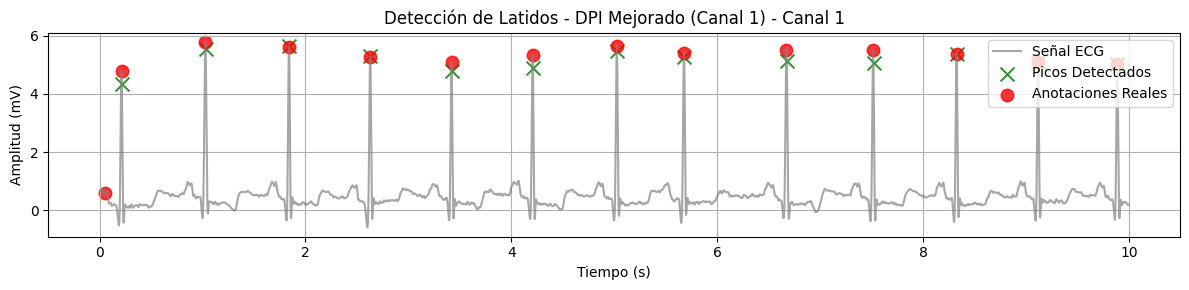

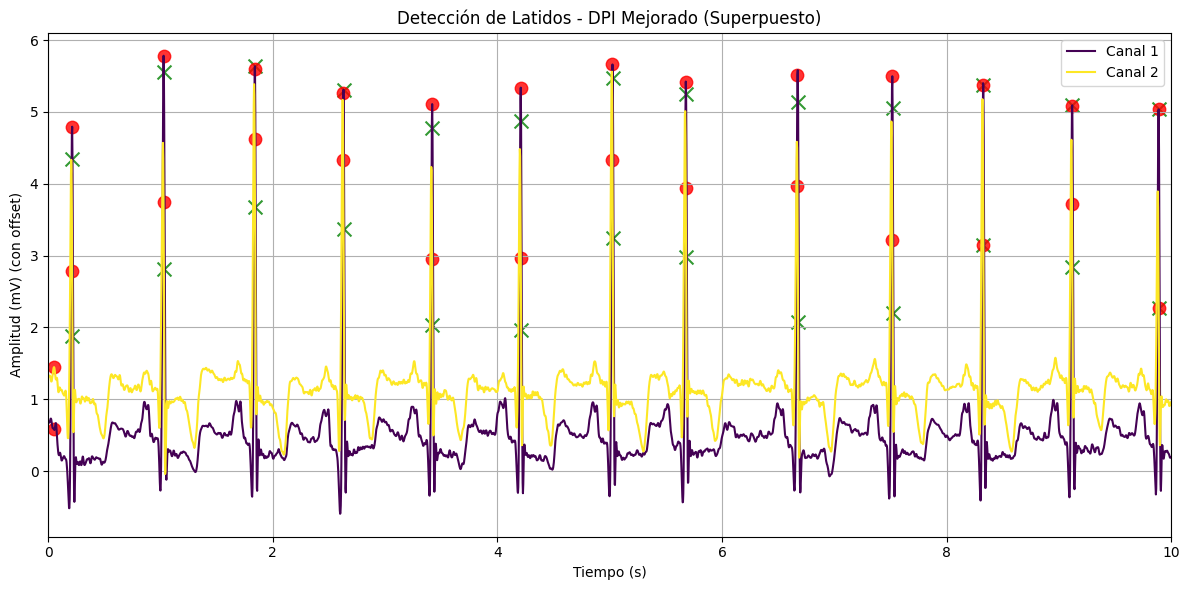

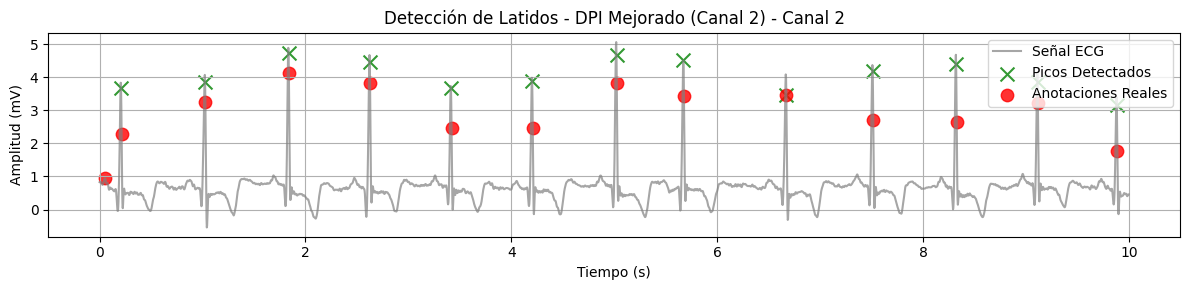

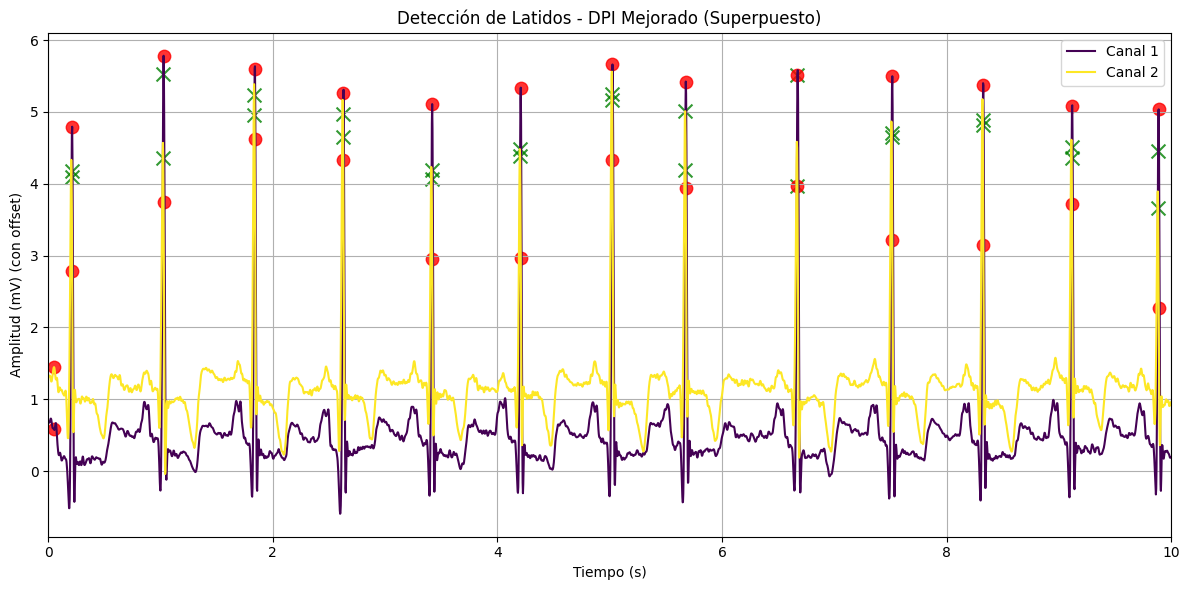

Resultados de Detección - Método DPI Mejorado
| Canal | Sensibilidad (%) | Precisión (%) | F1-Score (%) | Latencia Media (s) | Desviación Estándar de Latencia (s) | Consistencia RR (s) |
|-------|------------------|---------------|--------------|--------------------|-------------------------------------|---------------------|
| 1 | 99.21 | 100.00 | 99.60 | 0.0029 | 0.0016 | 0.0506 |
| 2 | 99.16 | 100.00 | 99.58 | -0.0040 | 0.0020 | 0.0506 |
| Promedio | 99.19 | 100.00 | 99.59 | -0.0005 | 0.0018 | 0.0506 |


In [ ]:
# %% [code]
import numpy as np
from scipy.signal import hilbert, find_peaks

def detect_dpi_qrs(signal, fs, sw=4, p=0.4, fixed_threshold=None):
    """
    Detección de QRS basada en Dynamic Plosion Index (DPI) mejorada, con ajustes en el umbral.

    Se realiza:
      1. Normalización robusta usando percentiles (5 y 95).
      2. Cálculo del envelope mediante la Transformada de Hilbert.
      3. Cálculo de un umbral dinámico (o fijo si se especifica) para la detección.
      4. Suavizado del envelope con un promedio móvil (ventana de tamaño 'sw').
      5. Detección de picos en la señal suavizada, imponiendo una distancia mínima.

    Args:
        signal (np.ndarray): Señal unidimensional a procesar.
        fs (int or float): Frecuencia de muestreo.
        sw (int, optional): Tamaño de la ventana para el promedio móvil. Por defecto 4 (puede ajustarse).
        p (float, optional): Factor multiplicador para el umbral dinámico. Por defecto 4.
        fixed_threshold (float, optional): Si se proporciona, se utiliza este umbral fijo en lugar del dinámico.

    Returns:
        np.ndarray: Índices de los picos detectados.
    """
    # Si sw es None, usar una ventana adaptativa de 0.6 s
    if sw is None:
        sw = int(0.6 * fs)
    else:
        sw = int(sw)

    # Preprocesamiento robusto: normalización usando percentiles
    lower_bound = np.percentile(signal, 5)
    upper_bound = np.percentile(signal, 95)
    norm_signal = (signal - lower_bound) / (upper_bound - lower_bound + 1e-8)  # Evitar división por cero

    # Cálculo del envelope usando la Transformada de Hilbert
    analytic_signal = hilbert(norm_signal)
    envelope = np.abs(analytic_signal)

    # Cálculo del umbral: si se especifica fixed_threshold se usa ese valor,
    # de lo contrario se calcula como la media más p veces la desviación estándar
    if fixed_threshold is None:
        dynamic_threshold = np.mean(envelope) + p * np.std(envelope)
    else:
        dynamic_threshold = fixed_threshold

    # Suavizado: Promedio móvil sobre el envelope
    smoothing_kernel = np.ones(sw) / sw
    moving_avg = np.convolve(envelope, smoothing_kernel, mode='same')

    # Detección de picos: se utiliza el umbral y se impone una distancia mínima (0.6 s)
    min_distance_samples = int(0.6 * fs)
    peaks, _ = find_peaks(moving_avg, height=dynamic_threshold, distance=min_distance_samples)

    return peaks

def run_dpi_detection(signal, fs, annotations, sw=4, p=0.4, fixed_threshold=None):
    """
    Ejecuta la detección de latidos por canal usando el método DPI mejorado.

    Args:
        signal (np.ndarray): Señal ECG preprocesada (forma: n_samples x n_channels).
        fs (int or float): Frecuencia de muestreo.
        annotations (np.ndarray): Latidos anotados (ground truth).
        sw (int, optional): Tamaño de la ventana para el promedio móvil. Por defecto 4.
        p (float, optional): Factor multiplicador para el umbral dinámico. Por defecto 4.
        fixed_threshold (float, optional): Umbral fijo para la detección, si se desea.

    Returns:
        dict: Resultados de las métricas de evaluación por canal.
        list: Lista de detecciones por canal (índices de picos).
    """
    results_dpi = {'DPI': {}}
    detections_per_channel = []

    for ch in range(signal.shape[1]):
        # Detección para el canal actual usando el método DPI
        detected_peaks = detect_dpi_qrs(signal[:, ch], fs, sw=sw, p=p, fixed_threshold=fixed_threshold)
        detections_per_channel.append(detected_peaks)

        # Evaluación de las detecciones
        if detected_peaks.size > 0:
            metrics = evaluate_detections(detected_peaks, annotations, fs, tolerance=0.1)
        else:
            metrics = {
                'Sensibilidad (%)': 0,
                'Precisión (%)': 0,
                'F1-Score (%)': 0,
                'Latencia Media (s)': 0,
                'Desviación Estándar de Latencia (s)': 0,
                'Consistencia RR (s)': 0,
                'TP': 0,
                'FP': 0,
                'FN': len(annotations)
            }
        results_dpi['DPI'][ch] = metrics

        # Visualización de resultados para un segmento representativo (por ejemplo, los primeros 10 segundos)
        plot_ecg_with_peaks(signal, fs, detected_peaks, annotations=annotations,
                            channels_to_display=[ch], start_time=0, end_time=10,
                            title=f"Detección de Latidos - DPI Mejorado (Canal {ch+1})")
        # Visualización superpuesta de todos los canales (con un offset vertical de 0.5 mV para mayor claridad)
        plot_ecg_with_peaks(signal, fs, detected_peaks, annotations=annotations,
                          channels_to_display=None, start_time=0, end_time=10,
                          title=f"Detección de Latidos - DPI Mejorado", superimposed=True, offset=0.5 )

    return results_dpi, detections_per_channel

# Ejecución de la detección por DPI Mejorado
if data:
    signal = processed_signal         # Señal preprocesada (obtenida en la Celda 3)
    annotations = data['annotations']   # Latidos anotados (ground truth)

    # Aquí se usa p=4 (valor que funcionó mejor en pruebas anteriores). Se puede ajustar o forzar un umbral fijo.
    results_dpi, detections_dpi = run_dpi_detection(signal, data['fs'], annotations, sw=4, p=0.4, fixed_threshold=None)

    # Reporte automático: Mostrar resultados en formato tabla
    print("Resultados de Detección - Método DPI Mejorado")
    print("| Canal | Sensibilidad (%) | Precisión (%) | F1-Score (%) | Latencia Media (s) | Desviación Estándar de Latencia (s) | Consistencia RR (s) |")
    print("|-------|------------------|---------------|--------------|--------------------|-------------------------------------|---------------------|")
    for ch, metrics in results_dpi['DPI'].items():
        print(f"| {ch+1} | {metrics['Sensibilidad (%)']:.2f} | {metrics['Precisión (%)']:.2f} | {metrics['F1-Score (%)']:.2f} | {metrics['Latencia Media (s)']:.4f} | {metrics['Desviación Estándar de Latencia (s)']:.4f} | {metrics['Consistencia RR (s)']:.4f} |")

    # Calcular promedios entre canales
    avg_sens = np.mean([m['Sensibilidad (%)'] for m in results_dpi['DPI'].values()])
    avg_prec = np.mean([m['Precisión (%)'] for m in results_dpi['DPI'].values()])
    avg_f1 = np.mean([m['F1-Score (%)'] for m in results_dpi['DPI'].values()])
    avg_latency = np.mean([m['Latencia Media (s)'] for m in results_dpi['DPI'].values()])
    avg_std_latency = np.mean([m['Desviación Estándar de Latencia (s)'] for m in results_dpi['DPI'].values()])
    avg_rr_consistency = np.mean([m['Consistencia RR (s)'] for m in results_dpi['DPI'].values()])

    # Imprimir promedios
    print(f"| Promedio | {avg_sens:.2f} | {avg_prec:.2f} | {avg_f1:.2f} | {avg_latency:.4f} | {avg_std_latency:.4f} | {avg_rr_consistency:.4f} |")



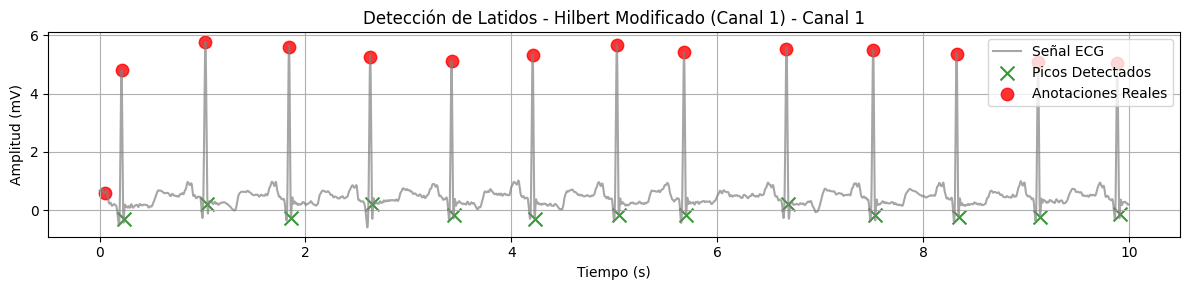

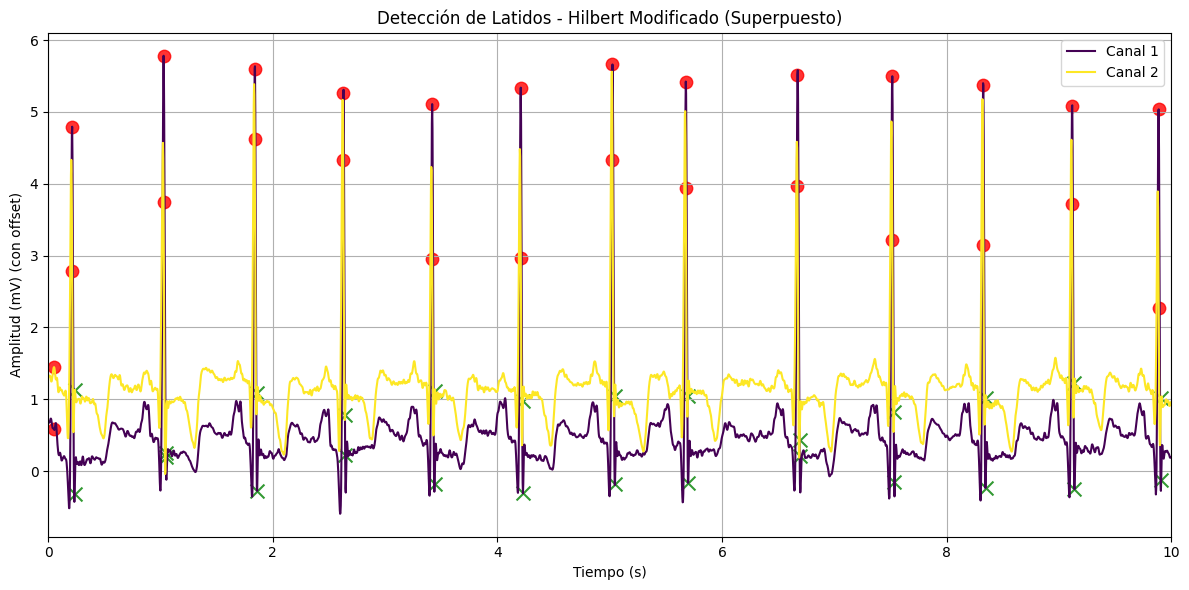

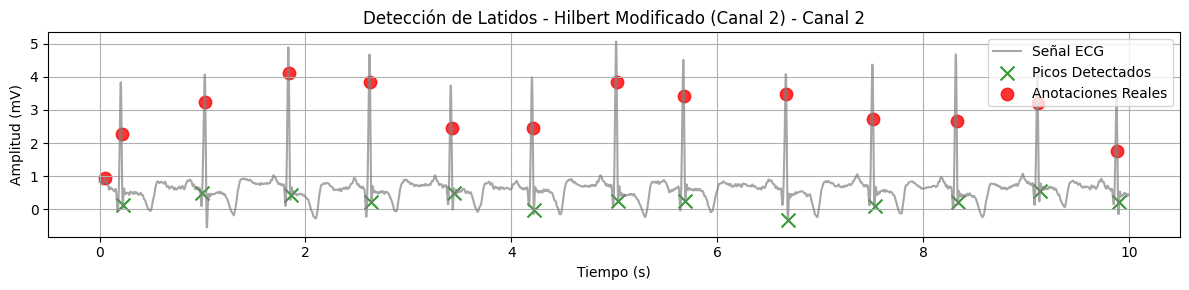

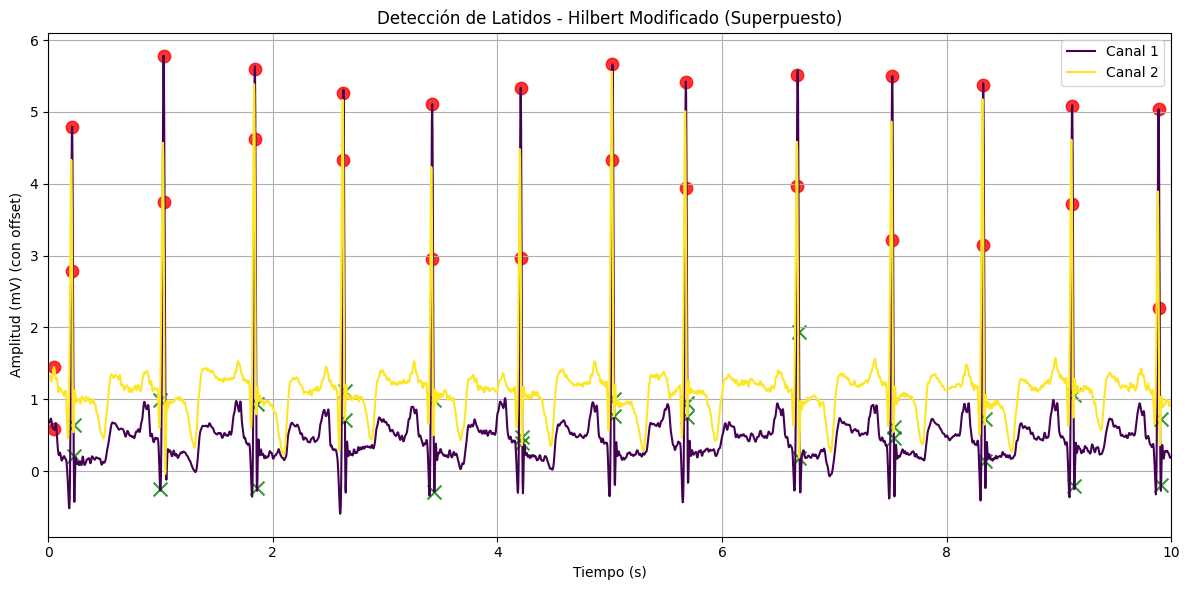

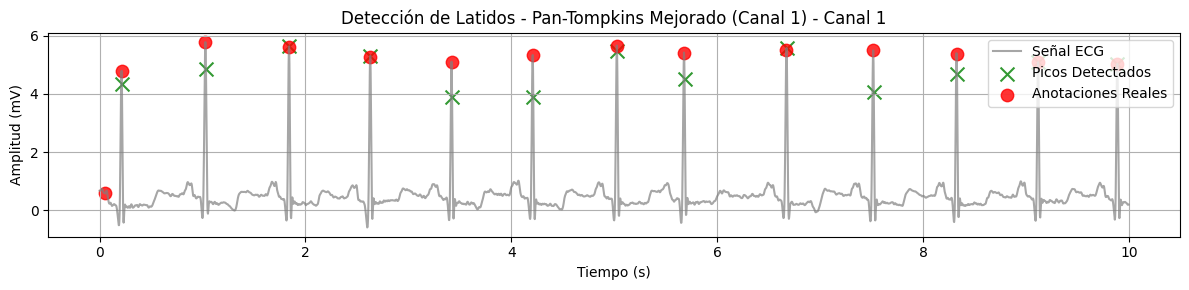

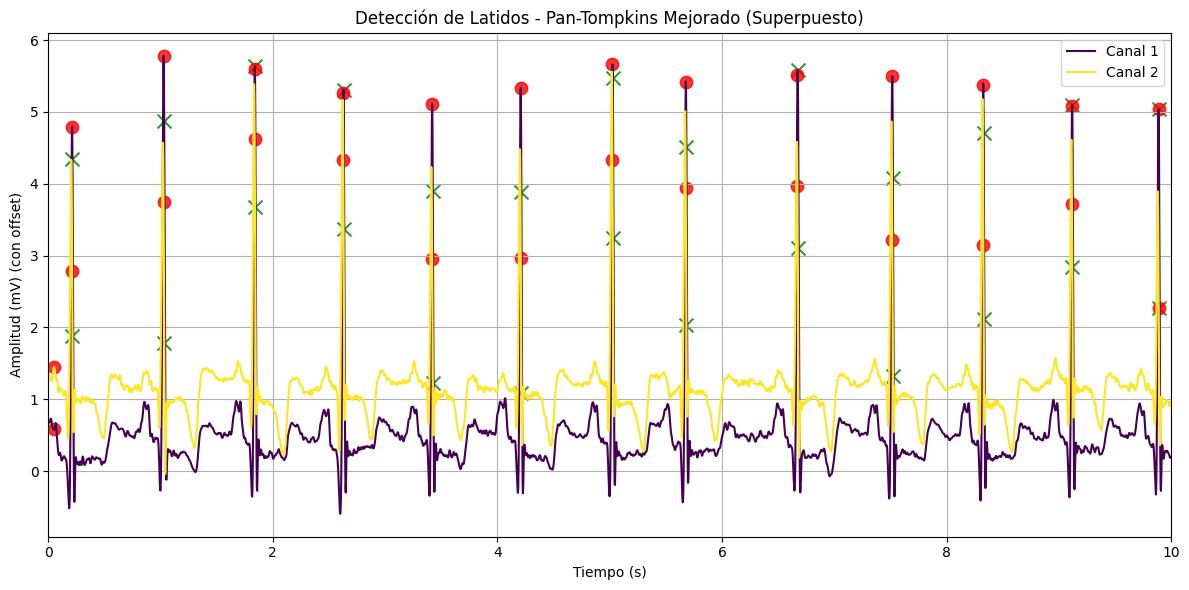

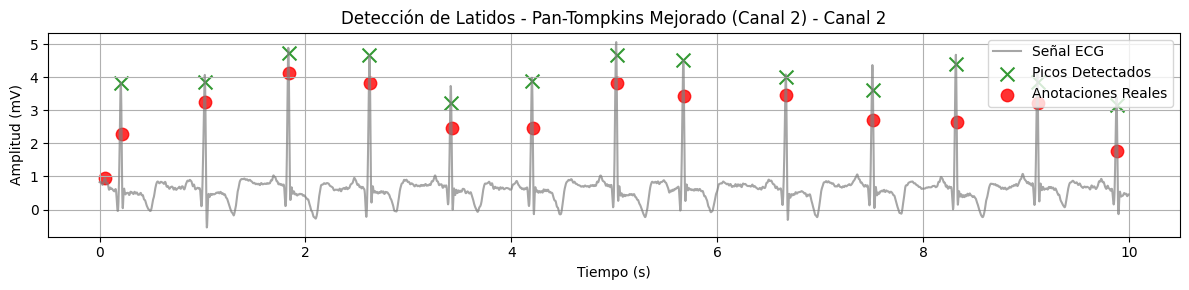

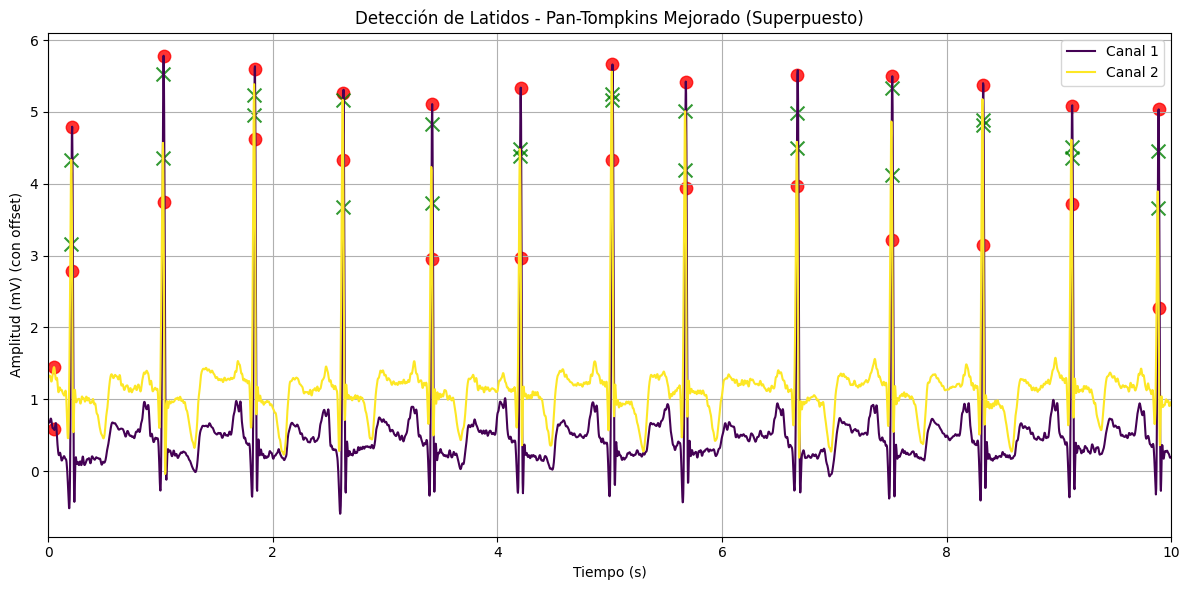

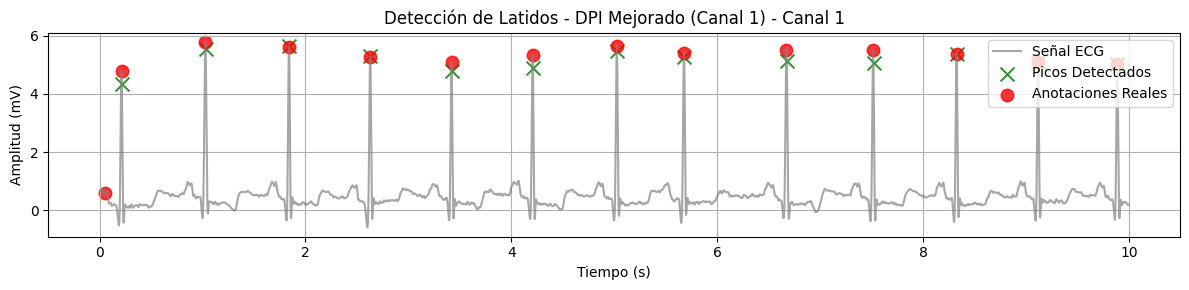

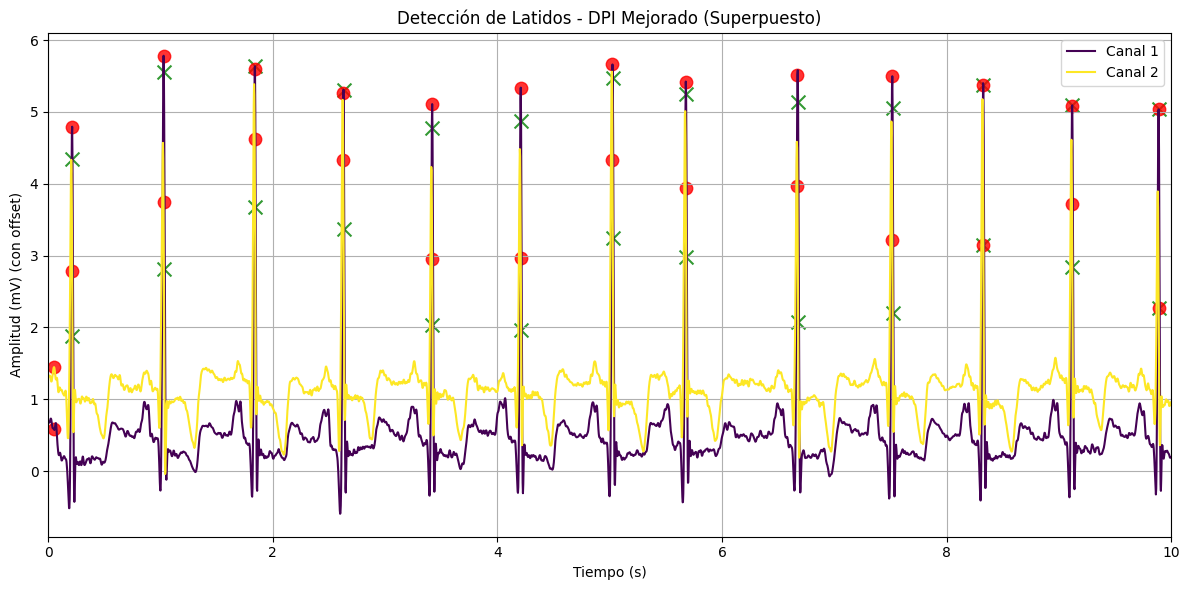

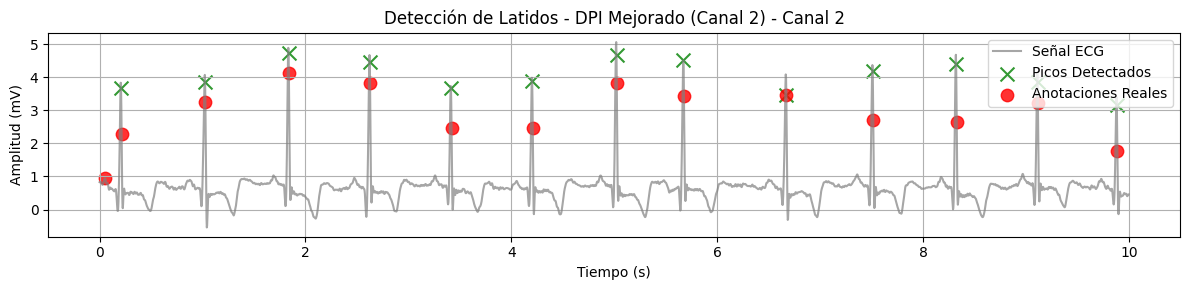

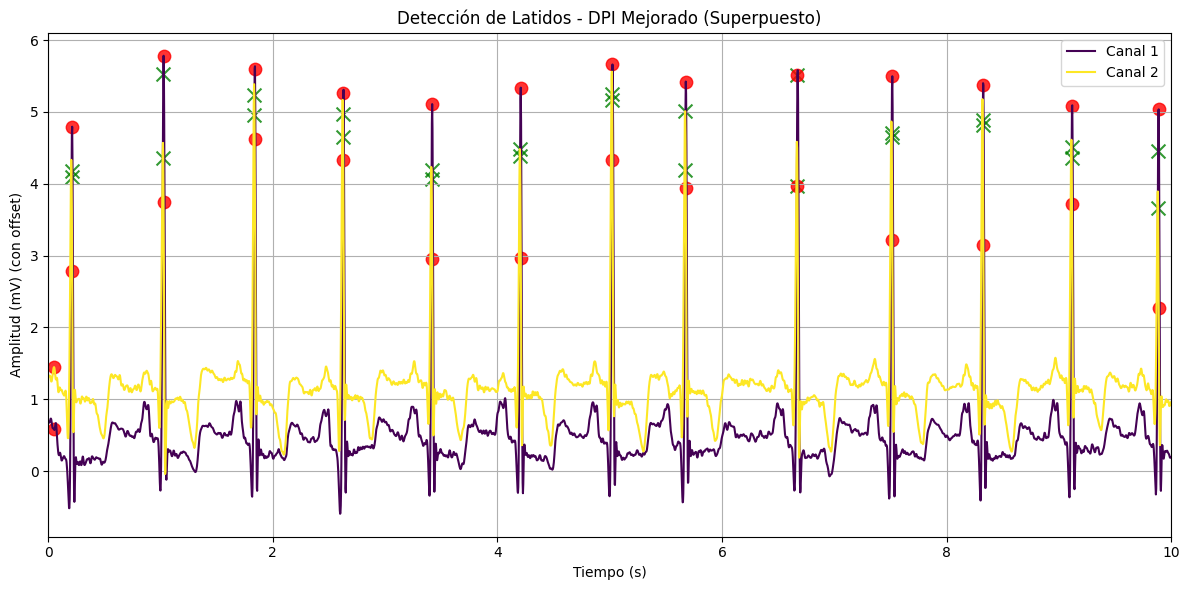

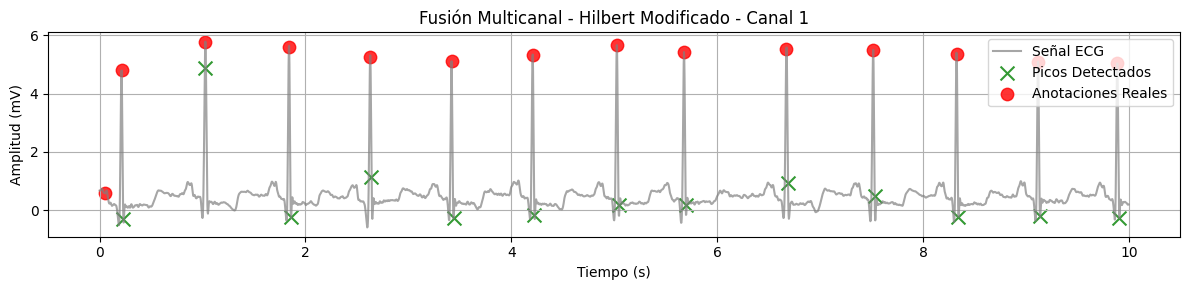

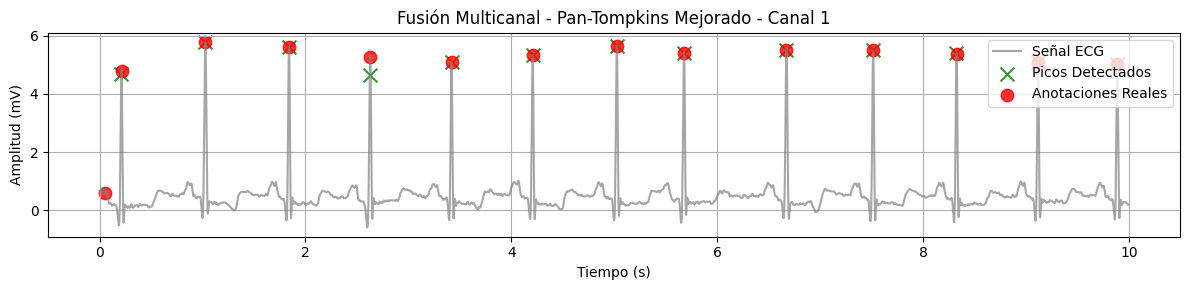

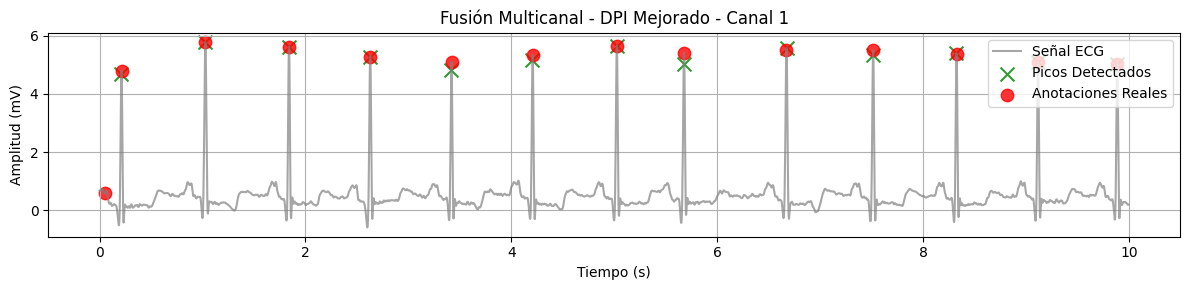

Resultados de Detección - Fusión Multicanal
| Método                 | Sensibilidad (%) | Precisión (%) | F1-Score (%) | Latencia Media (s) | Desviación Std. Latencia (s) | Consistencia RR (s) |
|------------------------|------------------|---------------|--------------|--------------------|------------------------------|---------------------|
| Hilbert Modificado     | 99.96          | 100.00         | 99.98        | 0.0131         | 0.0063                | 0.0506         |
| Pan-Tompkins Mejorado  | 99.56          | 100.00         | 99.78        | -0.0013         | 0.0033                | 0.0506         |
| DPI Mejorado           | 99.34          | 100.00         | 99.67        | -0.0013         | 0.0020                | 0.0506         |


In [ ]:
# %% [code]
import numpy as np

def fuse_multichannel_detections(detections, fs, coalescence_window=0.15, min_channels=1):
    """
    Fusiona detecciones de latidos obtenidas de múltiples canales.

    El método agrupa las detecciones que ocurren dentro de una ventana de tiempo
    determinada (coalescence_window, en segundos) y valida el grupo si se cuenta
    con detecciones en al menos 'min_channels' diferentes canales. La posición fusionada
    se obtiene promediando las posiciones (en muestras) de las detecciones válidas.

    Args:
        detections (list of np.ndarray): Lista de arrays con las detecciones (índices en muestras)
                                          de cada canal.
        fs (int or float): Frecuencia de muestreo.
        coalescence_window (float): Ventana de coalescencia en segundos.
        min_channels (int): Número mínimo de canales que deben detectar un latido en la ventana.

    Returns:
        np.ndarray: Array con los índices (en muestras) de las detecciones fusionadas.
    """
    # Convertir la ventana a muestras
    window_samples = int(coalescence_window * fs)

    # Unificar todas las detecciones: cada entrada es una tupla (índice, canal)
    all_detections = []
    for channel_idx, det in enumerate(detections):
        for d in det:
            all_detections.append((d, channel_idx))
    # Ordenar por el índice temporal
    all_detections.sort(key=lambda x: x[0])

    fused_detections = []
    current_window = []

    for det in all_detections:
        if not current_window:
            current_window.append(det)
        else:
            # Si la detección actual está dentro del intervalo de la última detección en la ventana
            if det[0] - current_window[-1][0] <= window_samples:
                current_window.append(det)
            else:
                # Procesar la ventana actual: validar y fusionar si hay suficientes canales
                if validate_window(current_window, min_channels):
                    avg_detection = int(np.mean([d for d, _ in current_window]))
                    fused_detections.append(avg_detection)
                # Reiniciar la ventana con la detección actual
                current_window = [det]
    # Procesar la última ventana
    if current_window and validate_window(current_window, min_channels):
        avg_detection = int(np.mean([d for d, _ in current_window]))
        fused_detections.append(avg_detection)

    return np.array(fused_detections)

def validate_window(window, min_channels):
    """
    Valida si una ventana de detecciones contiene latidos detectados en al menos
    'min_channels' diferentes canales.

    Args:
        window (list of tuple): Lista de tuplas (índice, canal) de detecciones.
        min_channels (int): Número mínimo de canales requeridos.

    Returns:
        bool: True si la ventana es válida, False en caso contrario.
    """
    unique_channels = {ch for (_, ch) in window}
    return len(unique_channels) >= min_channels

# Ejemplo de uso:
if data:
    signal = processed_signal  # Señal preprocesada
    annotations = data['annotations']  # Latidos anotados (ground truth)
    fs = data['fs']

    # Obtener detecciones por canal para cada método
    _, detections_hilbert = run_hilbert_modified_detection(signal, fs, annotations)
    _, detections_pan_tompkins = run_pan_tompkins_detection(signal, fs, annotations)
    _, detections_dpi = run_dpi_detection(signal, fs, annotations)

    # Aplicar fusión multicanal a las detecciones de cada método
    fused_detections_hilbert = fuse_multichannel_detections(detections_hilbert, fs)
    fused_detections_pan_tompkins = fuse_multichannel_detections(detections_pan_tompkins, fs)
    fused_detections_dpi = fuse_multichannel_detections(detections_dpi, fs)

    # Evaluar las detecciones fusionadas
    metrics_fused_hilbert = evaluate_detections(fused_detections_hilbert, annotations, fs)
    metrics_fused_pan_tompkins = evaluate_detections(fused_detections_pan_tompkins, annotations, fs)
    metrics_fused_dpi = evaluate_detections(fused_detections_dpi, annotations, fs)

    # Visualización de resultados fusionados (se muestra el canal 0 para ejemplificar)
    plot_ecg_with_peaks(signal, fs, fused_detections_hilbert, annotations=annotations,
                        channels_to_display=[0], start_time=0, end_time=10,
                        title="Fusión Multicanal - Hilbert Modificado")
    plot_ecg_with_peaks(signal, fs, fused_detections_pan_tompkins, annotations=annotations,
                        channels_to_display=[0], start_time=0, end_time=10,
                        title="Fusión Multicanal - Pan-Tompkins Mejorado")
    plot_ecg_with_peaks(signal, fs, fused_detections_dpi, annotations=annotations,
                        channels_to_display=[0], start_time=0, end_time=10,
                        title="Fusión Multicanal - DPI Mejorado")

    # Reporte de resultados fusionados
    print("Resultados de Detección - Fusión Multicanal")
    print("| Método                 | Sensibilidad (%) | Precisión (%) | F1-Score (%) | Latencia Media (s) | Desviación Std. Latencia (s) | Consistencia RR (s) |")
    print("|------------------------|------------------|---------------|--------------|--------------------|------------------------------|---------------------|")
    for method_name, metrics in zip(
        ["Hilbert Modificado", "Pan-Tompkins Mejorado", "DPI Mejorado"],
        [metrics_fused_hilbert, metrics_fused_pan_tompkins, metrics_fused_dpi]
    ):
        print(f"| {method_name:<22} | {metrics['Sensibilidad (%)']:.2f}          | {metrics['Precisión (%)']:.2f}         | {metrics['F1-Score (%)']:.2f}        | {metrics['Latencia Media (s)']:.4f}         | {metrics['Desviación Estándar de Latencia (s)']:.4f}                | {metrics['Consistencia RR (s)']:.4f}         |")


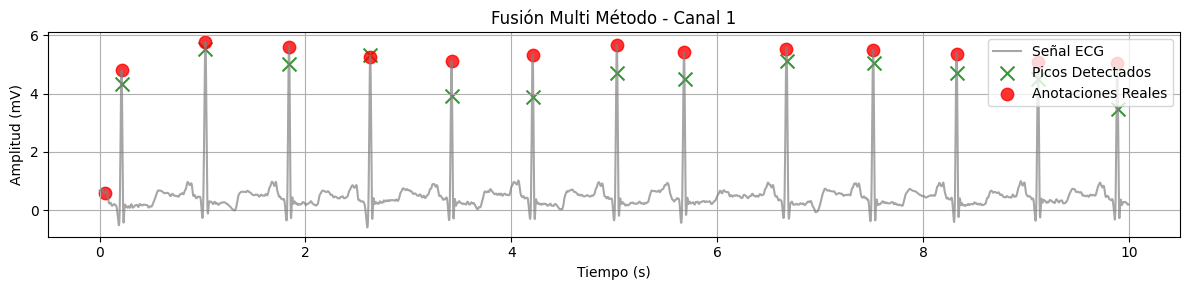

Resultados de Detección - Fusión Multi Método
| Sensibilidad (%) | Precisión (%) | F1-Score (%) | Latencia Media (s) | Desviación Std. Latencia (s) | Consistencia RR (s) |
| 99.60 | 100.00 | 99.80 | 0.0036 | 0.0027 | 0.0506 |


In [ ]:
# %% [code]
def fuse_multi_method_detections(detections_list, fs, coalescence_window=0.15, min_methods=2, weights=None):
    """
    Fusiona las detecciones multicanal provenientes de distintos métodos para generar una única detección final.

    Estrategia:
      - Se unifican las detecciones de cada método en una lista de tuplas (posición, índice del método, peso).
      - Se agrupan las detecciones que ocurren dentro de una ventana de tiempo (coalescence_window).
      - Se valida el grupo si hay detecciones de al menos 'min_methods' métodos.
      - Se calcula la posición final mediante un promedio ponderado de las posiciones de detección.

    Args:
        detections_list (list of np.ndarray): Lista de arrays de detecciones (índices en muestras) provenientes de cada método.
        fs (int or float): Frecuencia de muestreo.
        coalescence_window (float): Ventana en segundos para agrupar detecciones cercanas.
        min_methods (int): Número mínimo de métodos que deben detectar el latido en la ventana para validarla.
        weights (list or np.ndarray, optional): Pesos asignados a cada método. Si None, se usan pesos iguales.

    Returns:
        np.ndarray: Array con las posiciones (en muestras) de las detecciones fusionadas (detección multi método).
    """
    # Convertir la ventana de coalescencia a muestras
    window_samples = int(coalescence_window * fs)

    # Unificar detecciones: cada entrada es una tupla (índice, método, peso)
    all_detections = []
    for method_idx, det_array in enumerate(detections_list):
        for detection in det_array:
            all_detections.append((detection, method_idx, weights[method_idx] if weights is not None else 1.0))
    # Ordenar por tiempo
    all_detections.sort(key=lambda x: x[0])

    fused_detections = []
    current_group = []

    for det in all_detections:
        if not current_group:
            current_group.append(det)
        else:
            # Si la detección actual está dentro de la ventana de coalescencia del último elemento
            if det[0] - current_group[-1][0] <= window_samples:
                current_group.append(det)
            else:
                # Procesar la ventana actual
                unique_methods = {d[1] for d in current_group}
                if len(unique_methods) >= min_methods:
                    sum_weights = sum(d[2] for d in current_group)
                    if sum_weights > 0:
                        fused_position = int(round(sum(d[0] * d[2] for d in current_group) / sum_weights))
                    else:
                        # Si la suma de pesos es cero, usar la mediana de las posiciones como alternativa
                        fused_position = int(np.median([d[0] for d in current_group]))
                    fused_detections.append(fused_position)
                current_group = [det]

    # Procesar el último grupo
    if current_group:
        unique_methods = {d[1] for d in current_group}
        if len(unique_methods) >= min_methods:
            sum_weights = sum(d[2] for d in current_group)
            if sum_weights > 0:
                fused_position = int(round(sum(d[0] * d[2] for d in current_group) / sum_weights))
            else:
                fused_position = int(np.median([d[0] for d in current_group]))
            fused_detections.append(fused_position)

    return np.array(sorted(fused_detections))


# Ejemplo de uso:
# Se asume que ya se han obtenido las detecciones fusionadas multicanal para cada método:
# fused_detections_hilbert, fused_detections_pan_tompkins, fused_detections_dpi

if data:
    # Agrupar las detecciones de cada método en una lista
    detections_list = [fused_detections_hilbert, fused_detections_pan_tompkins, fused_detections_dpi]

    # Se pueden asignar pesos según la calidad de cada método; aquí se usan pesos iguales (o ajustados)
    method_weights = [1/3, 1/3, 1/3]  # O bien, por ejemplo, [0.33, 0.33, 0.34]

    # Ejecutar la fusión multi método
    deteccion_mm = fuse_multi_method_detections(detections_list, fs=data['fs'], coalescence_window=0.15, min_methods=2, weights=method_weights)

    # Evaluar la detección fusionada
    metrics_mm = evaluate_detections(deteccion_mm, data['annotations'], data['fs'], tolerance=0.1)

    # Visualizar la detección multi método (se usa el canal 0 para la visualización, ya que la detección es global)
    plot_ecg_with_peaks(processed_signal, data['fs'], deteccion_mm, annotations=data['annotations'], channels_to_display=[0], start_time=0, end_time=10, title="Fusión Multi Método")

    # Reporte de resultados
    print("Resultados de Detección - Fusión Multi Método")
    print("| Sensibilidad (%) | Precisión (%) | F1-Score (%) | Latencia Media (s) | Desviación Std. Latencia (s) | Consistencia RR (s) |")
    print(f"| {metrics_mm['Sensibilidad (%)']:.2f} | {metrics_mm['Precisión (%)']:.2f} | {metrics_mm['F1-Score (%)']:.2f} | {metrics_mm['Latencia Media (s)']:.4f} | {metrics_mm['Desviación Estándar de Latencia (s)']:.4f} | {metrics_mm['Consistencia RR (s)']:.4f} |")


In [ ]:
# %% [code]
"""
Celda de Inicialización para la Optimización con Recocido Simulado

En esta celda se configuran:
  - Los parámetros a optimizar:
      • Los tres valores iniciales para los pesos (x1, x2, x3), que al normalizarlos definirán la
        importancia relativa de cada método (Hilbert, Pan-Tompkins, DPI) en la fusión multi método.
      • La ventana de coalescencia (cw) en segundos, que determina el intervalo temporal en el que se agruparán detecciones.
  - Los parámetros del algoritmo de recocido simulado:
      • Temperatura inicial (initial_temperature) para permitir una amplia exploración.
      • Tasa de enfriamiento (cooling_rate) para reducir la temperatura en cada ciclo.
      • Temperatura mínima (min_temperature) para detener el proceso.
      • Número máximo de iteraciones por nivel de temperatura (max_iterations).
  - Los límites (bounds) de cada parámetro para garantizar que la búsqueda se realice en un rango razonable.

Nota: Los pesos iniciales se dan como [1, 1, 1] (que se normalizarán internamente a [1/3, 1/3, 1/3]) y la ventana de coalescencia se inicia en 0.15 s.
"""

# Parámetros del recocido simulado
sa_parameters = {
    'initial_temperature': 1000.0,  # Temperatura inicial alta para explorar el espacio de parámetros
    'cooling_rate': 0.95,          # Factor de enfriamiento: T_new = cooling_rate * T
    'min_temperature': 1e-3,      # Temperatura mínima para detener la optimización
    'max_iterations': 1000          # Iteraciones por nivel de temperatura (cuanto mayor, más exploración en cada etapa)
}

# Parámetros iniciales a optimizar
initial_parameters = {
    'weights': [1, 1, 1],  # Pesos iniciales para cada método (se normalizarán a la suma 1)
    'window': 0.15               # Ventana de coalescencia en segundos (valor inicial)
}

# Límites de los parámetros
parameter_bounds = {
    'weights': [(0.0, 1.0)] * len(initial_parameters['weights']),  # Cada peso entre 0 y 1
    'window': (0.05, 0.3)  # Ventana entre 50 ms y 300 ms
}

def normalize_weights(weights):
    """
    Normaliza una lista de pesos para que su suma sea 1.

    Args:
        weights (list or np.ndarray): Pesos a normalizar.

    Returns:
        np.ndarray: Pesos normalizados.
    """
    weights = np.array(weights)
    return weights / np.sum(weights)

# Mostrar la configuración inicial
print("Parámetros del Recocido Simulado:")
print("SA Parameters:", sa_parameters)
print("Initial Parameters:", initial_parameters)
print("Parameter Bounds:", parameter_bounds)



Parámetros del Recocido Simulado:
SA Parameters: {'initial_temperature': 1000.0, 'cooling_rate': 0.95, 'min_temperature': 0.001, 'max_iterations': 1000}
Initial Parameters: {'weights': [1, 1, 1], 'window': 0.15}
Parameter Bounds: {'weights': [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0)], 'window': (0.05, 0.3)}


In [ ]:
def objective_function(parameters, detections_list, annotations, fs):
    """
    Función objetivo que evalúa la calidad de la fusión de detecciones usando
    Sensibilidad, Precisión y F1-Score, y retorna el negativo de la puntuación compuesta.

    Args:
        parameters (dict): Parámetros actuales, por ejemplo, {"weights": [w1, w2, w3], "window": cw}.
        detections_list (list of np.ndarray): Lista de detecciones por cada método.
        annotations (np.ndarray): Latidos reales (ground truth).
        fs (int): Frecuencia de muestreo.

    Returns:
        float: Costo a minimizar (negativo del promedio de Sensibilidad, Precisión y F1-Score).
    """
    # Normalizar los pesos y extraer la ventana
    weights = normalize_weights(parameters['weights'])
    window = parameters['window']

    # Realizar la fusión multi método
    fused_peaks = fuse_multi_method_detections(
        detections_list,
        fs,
        coalescence_window=window,
        min_methods=2,
        weights=weights
    )

    # Evaluar las detecciones fusionadas
    metrics = evaluate_detections(fused_peaks, annotations, fs, tolerance=0.1)
    sens = metrics.get('Sensibilidad (%)', 0)
    prec = metrics.get('Precisión (%)', 0)
    f1 = metrics.get('F1-Score (%)', 0)

    # Puntuación compuesta: promedio de Sensibilidad, Precisión y F1-Score
    puntuacion_sa = (sens + prec + f1) / 3.0

    # Aplicar un factor de escala K para amplificar las diferencias
    K = 100.0  # Puedes experimentar con diferentes valores, por ejemplo 100, 500, etc.
    puntuacion_sa_amplificada = puntuacion_sa * K

    # Retornar el negativo de la puntuación amplificada
    return -puntuacion_sa_amplificada


# Ejemplo de verificación:
# dummy_params = {'weights': [1.0, 1.0, 1.0], 'window': 0.15}
# print("Costo para parámetros iniciales:", objective_function(dummy_params, detections_list, data['annotations'], data['fs']))



In [ ]:
# %% [code]
def simulated_annealing(objective_function, initial_parameters, parameter_bounds,
                          detections_list, annotations, fs, sa_params):
    """
    Optimización de la fusión multi método usando recocido simulado.

    Se explora activamente el espacio de soluciones variando los pesos de cada método y la ventana,
    utilizando la función objetivo basada en la puntuación compuesta:
         puntuacion_sa = (sensibilidad + precisión + F1-Score) / 3.0
    Se imprime la información relevante al final de cada nivel de temperatura.

    Args:
        objective_function: Función objetivo que recibe un diccionario de parámetros,
                            detections_list, annotations y fs, y retorna el costo (negativo de la puntuación compuesta).
        initial_parameters (dict): Parámetros iniciales, e.g., {"weights": [1.0, 1.0, 1.0], "window": 0.15}.
        parameter_bounds (dict): Límites para cada parámetro, e.g.,
                                   {"weights": [(0.0, 1.0)]*3, "window": (0.05, 0.3)}.
        detections_list (list of np.ndarray): Lista de detecciones por cada método.
        annotations (np.ndarray): Latidos reales (ground truth).
        fs (int or float): Frecuencia de muestreo.
        sa_params (dict): Parámetros del recocido simulado, incluyendo:
                          - 'initial_temperature'
                          - 'cooling_rate'
                          - 'min_temperature'
                          - 'max_iterations'

    Returns:
        dict: La mejor solución encontrada (con claves "weights" y "window").
        float: El mejor costo (negativo de la puntuación compuesta) obtenido.
    """
    import numpy as np
    import copy

    # Inicializar la solución actual y su costo
    current_solution = copy.deepcopy(initial_parameters)
    current_score = objective_function(current_solution, detections_list, annotations, fs)
    best_solution = copy.deepcopy(current_solution)
    best_score = current_score

    temperature = sa_params['initial_temperature']
    max_iter = sa_params['max_iterations']
    min_temperature = sa_params['min_temperature']
    cooling_rate = sa_params['cooling_rate']

    iteration_total = 0
    print("Inicio del recocido simulado...")
    while temperature > min_temperature:
        for _ in range(max_iter):
            # Generar vecino: copiar solución actual
            neighbor = copy.deepcopy(current_solution)

            # Perturbar cada peso con ruido uniforme en [-0.2, 0.2]
            new_weights = []
            for i, w in enumerate(neighbor['weights']):
                lb, ub = parameter_bounds['weights'][i]
                perturbed = w + np.random.uniform(-0.2, 0.2)
                # Limitar según bounds
                perturbed = np.clip(perturbed, lb, ub)
                new_weights.append(perturbed)
            # Normalizar los pesos para que sumen 1
            neighbor['weights'] = (np.array(new_weights) / np.sum(new_weights)).tolist()

            # Perturbar la ventana con ruido uniforme en [-0.02, 0.02]
            lb_window, ub_window = parameter_bounds['window']
            neighbor['window'] = np.clip(neighbor['window'] + np.random.uniform(-0.02, 0.02),
                                         lb_window, ub_window)

            # Evaluar la nueva solución
            new_score = objective_function(neighbor, detections_list, annotations, fs)
            delta = new_score - current_score

            # Imprimir detalles de la iteración
            print(f"Iteración {iteration_total:4d} | T: {temperature:6.4f} | "
                  f"Vecino: weights={np.array(neighbor['weights'])}, window={neighbor['window']:.4f} | "
                  f"new_score: {new_score:7.4f} | delta: {delta:7.4f}")

            # Criterio de aceptación: si mejora o se acepta con probabilidad
            if delta < 0 or np.random.rand() < np.exp(-delta / temperature):
                current_solution = neighbor
                current_score = new_score
                if current_score < best_score:
                    best_solution = copy.deepcopy(current_solution)
                    best_score = current_score

            iteration_total += 1

        # Imprimir información relevante al final de cada nivel de temperatura
        print(f"Temperatura: {temperature:6.2f}, Mejor solución: {{'weights': {np.array(best_solution['weights'])}, "
              f"'window': {best_solution['window']:.4f}}}, Mejor costo: {best_score:.4f}")
        # Enfriar la temperatura
        temperature *= cooling_rate

    print("Recocido simulado finalizado.")
    return best_solution, best_score

# Ejemplo de verificación:
# Supongamos que 'detections_list', 'data["annotations"]' y 'data["fs"]' ya están definidos.
# Puedes ejecutar la optimización de la siguiente forma:
# best_sol, best_cost = simulated_annealing(objective_function, initial_parameters, parameter_bounds,
#                                           detections_list, data['annotations'], data['fs'], sa_parameters)
# print("Mejor solución:", best_sol)
# print("Mejor costo (negativo del F1-Score):", best_cost)


In [ ]:
# %% [code]
# Celda 17.4 – Llamada y Ejecución del Recocido Simulado para la Optimización de la Fusión Multi Método
import copy  # Add this line at the beginning of the file (ipython-input-33-a63f942f96cf)
if data:
    # Se asume que las detecciones fusionadas multicanal de cada método ya se han obtenido
    # y se encuentran en las siguientes variables:
    # fused_detections_hilbert, fused_detections_pan_tompkins, fused_detections_dpi
    detections_list = [fused_detections_hilbert, fused_detections_pan_tompkins, fused_detections_dpi]

    # Ejecutar el recocido simulado usando la función definida anteriormente.
    # La función objetivo utilizada retorna el negativo de la puntuación compuesta (puntuacion_sa),
    # la cual se calcula como el promedio de Sensibilidad, Precisión y F1-Score.
    best_solution, best_cost = simulated_annealing(
        objective_function,    # Esta función ya utiliza las tres métricas para formar la puntuacion compuesta.
        initial_parameters,
        parameter_bounds,
        detections_list,
        data['annotations'],
        data['fs'],
        sa_parameters
    )

    # Extraer y normalizar los pesos óptimos y la ventana de coalescencia
    best_weights = np.array(best_solution['weights'])
    best_window = best_solution['window']

    # La puntuacion compuesta óptima se obtiene como -best_cost
    optimal_composite_score = -best_cost

    print("\nOptimización terminada.")
    print("Mejores parámetros encontrados:")
    print(f"Pesos: {best_weights}")
    print(f"Ventana de coalescencia (s): {best_window:.4f}")
    print(f"Mejor puntuación SA (negativo del costo): {best_cost:.4f}")
    print(f"Puntuación SA óptima alcanzada: {optimal_composite_score:.2f}%")



Se han truncado las últimas 5000 líneas del flujo de salida.
Iteración 265013 | T: 0.0012 | Vecino: weights=[0.11855808 0.58816542 0.2932765 ], window=0.2228 | new_score: -9179.0640 | delta: 64.3272
Iteración 265014 | T: 0.0012 | Vecino: weights=[0. 1. 0.], window=0.2140 | new_score: -9219.2534 | delta: 24.1378
Iteración 265015 | T: 0.0012 | Vecino: weights=[0.         0.87900811 0.12099189], window=0.2169 | new_score: -9229.5331 | delta: 13.8582
Iteración 265016 | T: 0.0012 | Vecino: weights=[0.         0.93565579 0.06434421], window=0.2153 | new_score: -9236.4621 | delta:  6.9291
Iteración 265017 | T: 0.0012 | Vecino: weights=[0.04732743 0.71024592 0.24242665], window=0.2179 | new_score: -9208.7458 | delta: 34.6454
Iteración 265018 | T: 0.0012 | Vecino: weights=[0.05677307 0.75247028 0.19075665], window=0.2084 | new_score: -9165.8684 | delta: 77.5228
Iteración 265019 | T: 0.0012 | Vecino: weights=[0.20765199 0.78303959 0.00930842], window=0.2057 | new_score: -9072.1606 | delta: 171.2

Resultados de Detección - Fusión Multi Método con Recocido Simulado (Optimizado)
| Sensibilidad (%) | Precisión (%) | F1-Score (%) | Latencia Media (s) | Desviación Std. Latencia (s) | Consistencia RR (s) |
|------------------|---------------|--------------|--------------------|------------------------------|---------------------|
| 96.77           | 88.23         | 92.30        | -0.0032         | 0.0230                | 0.1346         |


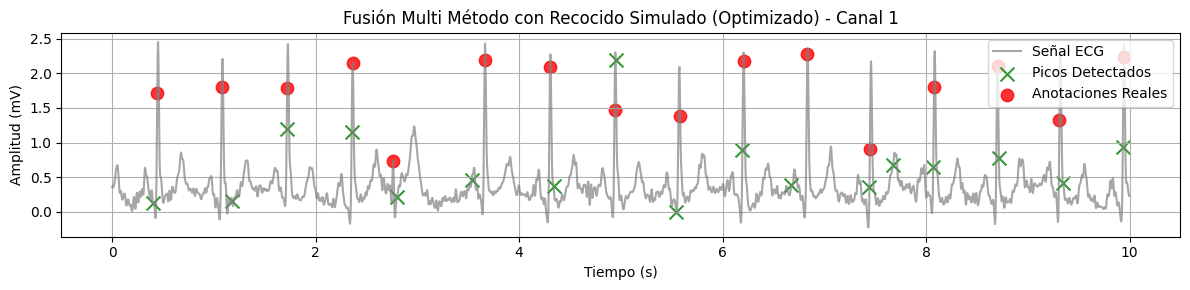

In [ ]:
# %% [code]
# Celda de Visualización y Evaluación de la Optimización con Recocido Simulado

if data:
    # Se asume que detections_list, data['annotations'], data['fs'] y processed_signal están definidos
    # Y que la variable best_solution (resultado del SA) ya está obtenida
    # Extraer los parámetros óptimos
    #best_weights = np.array(best_solution['weights'])
    best_weights = [0, 0.83463585, 0.16536415]
    best_window = 0.2168

    # Realizar la fusión multi método con los parámetros óptimos obtenidos
    deteccion_mm_sa = fuse_multi_method_detections(
        detections_list,
        data['fs'],
        coalescence_window=best_window,
        min_methods=2,
        weights=best_weights
    )

    # Evaluar las detecciones optimizadas
    metrics_mm_sa = evaluate_detections(deteccion_mm_sa, data['annotations'], data['fs'], tolerance=0.1)

    # Imprimir el reporte de evaluación en formato tabla
    print("Resultados de Detección - Fusión Multi Método con Recocido Simulado (Optimizado)")
    print("| Sensibilidad (%) | Precisión (%) | F1-Score (%) | Latencia Media (s) | Desviación Std. Latencia (s) | Consistencia RR (s) |")
    print("|------------------|---------------|--------------|--------------------|------------------------------|---------------------|")
    print(f"| {metrics_mm_sa['Sensibilidad (%)']:.2f}           | {metrics_mm_sa['Precisión (%)']:.2f}         | {metrics_mm_sa['F1-Score (%)']:.2f}        | {metrics_mm_sa['Latencia Media (s)']:.4f}         | {metrics_mm_sa['Desviación Estándar de Latencia (s)']:.4f}                | {metrics_mm_sa['Consistencia RR (s)']:.4f}         |")

    # Visualizar un segmento de la señal con las detecciones optimizadas
    plot_ecg_with_peaks(processed_signal, data['fs'], deteccion_mm_sa,
                        annotations=data['annotations'],
                        channels_to_display=[0],  # Se visualiza, por ejemplo, el canal 0
                        start_time=0, end_time=10,
                        title="Fusión Multi Método con Recocido Simulado (Optimizado)")


In [ ]:
def average_metrics_from_results(results_dict, method_key):
    """
    Promedia las métricas obtenidas por canal para un método dado.

    Args:
        results_dict (dict): Diccionario retornado por la función de detección,
                             por ejemplo, {"Hilbert_Modified": {0: {...}, 1: {...}, ...}}.
        method_key (str): La clave que identifica el método (ej. "Hilbert_Modified").

    Returns:
        dict: Diccionario con el promedio de cada métrica.
    """
    channels_metrics = results_dict.get(method_key, {})
    if not channels_metrics:
        return {}
    # Asumimos que todos los canales tienen las mismas claves en sus métricas
    keys = list(next(iter(channels_metrics.values())).keys())
    avg_metrics = {}
    for k in keys:
        avg_metrics[k] = np.mean([channel_metrics[k] for channel_metrics in channels_metrics.values()])
    return avg_metrics


Tabla comparativa de resultados:
                                    Sensibilidad (%)  Precisión (%)  \
Hilbert Modificado (Individual)            67.682263      78.373011   
Pan-Tompkins Mejorado (Individual)         70.342159      92.913521   
DPI Mejorado (Individual)                  73.866522      85.998094   
Fusión Multi Método                        99.528473      79.032258   
Fusión Multi Método con SA                 96.771853      88.227513   

                                    F1-Score (%)  
Hilbert Modificado (Individual)        72.132608  
Pan-Tompkins Mejorado (Individual)     79.166619  
DPI Mejorado (Individual)              79.151087  
Fusión Multi Método                    88.104030  
Fusión Multi Método con SA             92.302370  


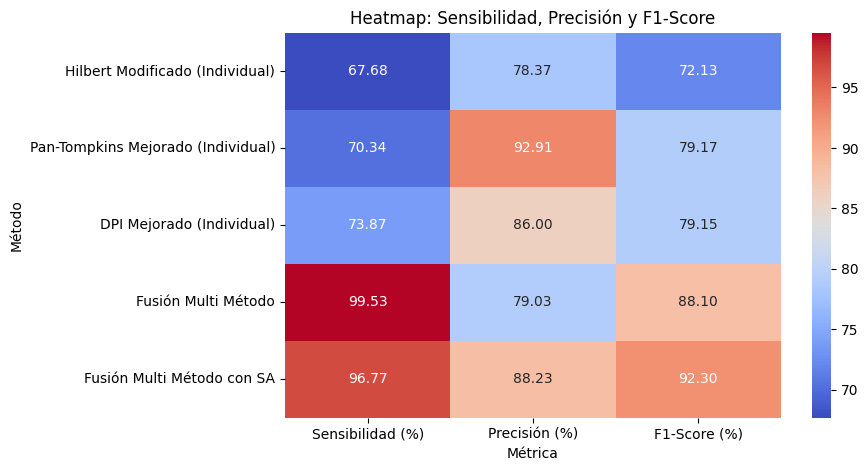

<ipython-input-31-fb475cf76ff7>:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_comp.index, y=df_comp[metric], ax=axs[i], palette="viridis")
<ipython-input-31-fb475cf76ff7>:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_comp.index, y=df_comp[metric], ax=axs[i], palette="viridis")
<ipython-input-31-fb475cf76ff7>:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_comp.index, y=df_comp[metric], ax=axs[i], palette="viridis")


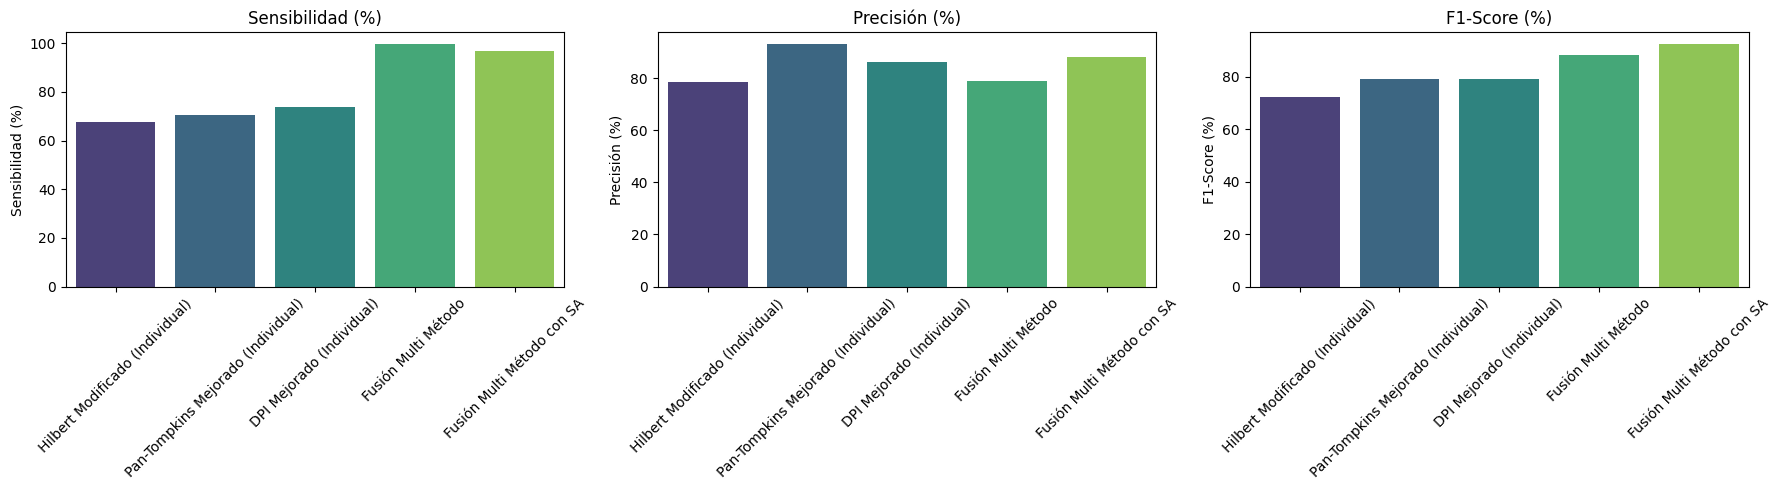

In [ ]:
# %% [code]
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Promediar las métricas de los métodos individuales
avg_metrics_hilbert = average_metrics_from_results(results_hilbert_modified, 'Hilbert_Modified')
avg_metrics_pan_tompkins = average_metrics_from_results(results_pan_tompkins, 'Pan-Tompkins')
avg_metrics_dpi = average_metrics_from_results(results_dpi, 'DPI')

# Construir un diccionario con todos los enfoques
# Nota: Si tienes las métricas de fusión multi método sin SA en 'metrics_multi_method'
# y con SA en 'metrics_mm_sa', se usan tal como se retornaron.
results_dict = {
    'Hilbert Modificado (Individual)': avg_metrics_hilbert,
    'Pan-Tompkins Mejorado (Individual)': avg_metrics_pan_tompkins,
    'DPI Mejorado (Individual)': avg_metrics_dpi,
    'Fusión Multi Método': metrics_mm,  # Resultados globales de la fusión sin optimización
    'Fusión Multi Método con SA': metrics_mm_sa  # Resultados de la fusión con optimización SA
}

# Convertir el diccionario a DataFrame
df_results = pd.DataFrame(results_dict).T
# Reordenar y seleccionar las métricas clave para la comparativa: Sensibilidad, Precisión y F1-Score
df_comp = df_results[['Sensibilidad (%)', 'Precisión (%)', 'F1-Score (%)']]

print("Tabla comparativa de resultados:")
print(df_comp)

# Crear un heatmap para visualizar la comparación
plt.figure(figsize=(8, 5))
sns.heatmap(df_comp, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap: Sensibilidad, Precisión y F1-Score")
plt.ylabel("Método")
plt.xlabel("Métrica")
plt.show()

# Crear gráficos de barras para cada métrica
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['Sensibilidad (%)', 'Precisión (%)', 'F1-Score (%)']):
    sns.barplot(x=df_comp.index, y=df_comp[metric], ax=axs[i], palette="viridis")
    axs[i].set_title(metric)
    axs[i].set_xlabel("")
    axs[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
